In [1]:
!pip install pycddlib-standalone 
!pip install torch --index-url https://download.pytorch.org/whl/cu128
!pip install gymnasium mo-gymnasium tqdm numpy matplotlib pymoo wandb ipywidgets cvxpy fire imageio moviepy pygame pymoo scipy seaborn sortedcontainers torch wandb
!pip install git+https://github.com/LucasAlegre/morl-baselines.git --no-deps

  Using cached pycddlib_standalone-3.0.0.tar.gz (90 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for pycddlib-standalone: filename=pycddlib_standalone-3.0.0-cp312-cp312-win_amd64.whl size=126805 sha256=c9c781ca1c3945d6b8453b7c3ffbd86c7a3f938aa633c00004949b8bb9b71ae4
  Stored in directory: c:\users\skakr\appdata\local\pip\cache\wheels\21\2a\7d\f2886a252eda8766707c21cdfd69d58330ec9b78a2bde292c4
Successfully built pycddlib-standalone
Looking in indexes: https://download.pytorch.org/whl/cu128
^C


In [22]:
import gymnasium as gym
import numpy as np
from morl_baselines.multi_policy.morld.morld import MORLD
from tqdm.auto import tqdm
import wandb

In [23]:
# config 
TOTAL_TIMESTEPS = int(1e5)
MAX_EPISODE_LENGTH = 8
EXPERIMENT_NAME = f"small_MORL-D_{TOTAL_TIMESTEPS}"
POP_SIZE = 10
EXCHANGE_EVERY = 1000

In [24]:
# visualize front

import wandb
import numpy as np
import matplotlib.pyplot as plt


def visualize_front_general(pareto_front, columns):
    pf_arr = np.array((list(pareto_front)))

    # 1) Build a W&B table
    pf_table = wandb.Table(columns=columns, data=pf_arr)

    # 2) Log 2D Pareto front projections as scatter plots
    # go through all combinations of columns
    n_pairs = len(columns) * (len(columns) - 1) // 2
    fig, axs = plt.subplots(1, n_pairs, figsize=(5 * n_pairs, 4))
    if n_pairs == 1: # subscriptable even if there's only 1 element
        axs = [axs]

    pair_count = 0
    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            wandb.log(
                {
                    f"pf_{columns[i]}_vs_{columns[j]}": wandb.plot.scatter(
                        pf_table,
                        x=columns[i],
                        y=columns[j],
                        title=f"Pareto front: {columns[i]} vs {columns[j]}",
                    )
                }
            )
            ax = axs[pair_count]
            ax.scatter(pf_arr[:, i], pf_arr[:, j], color="black")
            ax.set_xlabel(columns[i])
            ax.set_ylabel(columns[j])
            ax.set_title(f"Pareto front: {columns[i]} vs {columns[j]}")
                        
            pair_count += 1

    plt.show()
    plt.close(fig)
    return fig

def visualize_front(pareto_front):
    # pareto_front is currently a set of (d, g, di)
    pf_list = sorted(list(pareto_front))  # optional sort, just for consistency

    # 1) Build a W&B table
    pf_table = wandb.Table(columns=["death_penalty", "gold", "diamond"])
    for d, g, di in pf_list:
        pf_table.add_data(d, g, di)

    # 2) Log 2D Pareto front projections as scatter plots
    wandb.log({
        # color according to 3rd objective
        # Death penalty vs Gold
        "pareto_front_death_vs_gold": wandb.plot.scatter(
            pf_table,
            x="death_penalty",
            y="gold",
            title="Pareto front: death penalty vs gold",
        ),
        # Death penalty vs Diamond
        "pareto_front_death_vs_diamond": wandb.plot.scatter(
            pf_table,
            x="death_penalty",
            y="diamond",
            title="Pareto front: death penalty vs diamond",
        ),
        # Gold vs Diamond (often the most interesting trade-off)
        "pareto_front_gold_vs_diamond": wandb.plot.scatter(
            pf_table,
            x="gold",
            y="diamond",
            title="Pareto front: gold vs diamond",
        ),

    })

    pf_arr = np.array(pf_list)
    fig, axs = plt.subplots(1, 3)
    fig.set_figwidth(18)
    fig.set_figheight(5)
    axs[0].scatter(pf_arr[:, 0], pf_arr[:, 1])
    axs[1].scatter(pf_arr[:, 0], pf_arr[:, 2])
    axs[2].scatter(pf_arr[:, 1], pf_arr[:, 2])

    # axs[0].set_title(f"Pareto front for gamma")

    axs[0].set_xlabel("death_penalty")
    axs[1].set_xlabel("death_penalty")
    axs[2].set_xlabel("gold")

    axs[0].set_ylabel("gold")
    axs[1].set_ylabel("diamond")
    axs[2].set_ylabel("diamond")

    plt.show()


    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(pf_arr[:, 0], pf_arr[:, 1], pf_arr[:, 2])
    ax.set_xlabel("death_penalty")
    ax.set_ylabel("gold")
    ax.set_zlabel("diamond")
    ax.set_title("Pareto front")

    wandb.log({"pareto_front_3d": wandb.Image(fig)})

    plt.close(fig)

In [25]:
# eval.py

from typing import Optional, List
import gymnasium as gym
from morl_baselines.common.evaluation import (
    cardinality,
    expected_utility,
    hypervolume,
    igd,
    maximum_utility_loss,
)
from morl_baselines.common.pareto import ParetoArchive, filter_pareto_dominated, get_non_dominated_inds
from morl_baselines.common.scalarization import weighted_sum
from morl_baselines.common.weights import equally_spaced_weights
import numpy as np

from morl_baselines.multi_policy.morld.morld import Policy
from pymoo.util.ref_dirs import get_reference_directions
import wandb


def eval_full_four_room(agent, n_evaluation_episodes=5):
    test_env = gym.wrappers.TimeLimit(
        gym.make("my-four-room-v0", render_mode="human"), max_episode_steps=MAX_EPISODE_LENGTH, 
    )
    # get weight of the policy and the corresponding returns for each policy in the population
    returns = np.zeros((len(agent.population), 10), dtype=object) #  2 for weight, 4 for avg_vec_return, 4 for avg_disc_vec_return

    for j, policy in enumerate(agent.population):
        # evaluate the policy: get averages over n_evaluation_episodes episodes
        policy_evals = np.zeros((n_evaluation_episodes, 8))  # to store (vec_return, disc_vec_return) for each episode
        for i in range(n_evaluation_episodes):
            obs, _ = test_env.reset()
            done = False
            vec_return, disc_vec_return = np.zeros(4), np.zeros(4)
            gamma = 1.0

            while not done:
                obs, r, terminated, truncated, info = test_env.step(policy.wrapped.eval(obs))
                done = terminated or truncated
                vec_return += r
                disc_vec_return += gamma * r
                gamma *= policy.wrapped.gamma

        policy_evals[i][0:4] = vec_return
        policy_evals[i][4:8] = disc_vec_return

        avg_vec_return = np.mean(policy_evals[:, 0:4], axis=0)
        avg_disc_vec_return = np.mean(policy_evals[:, 4:8], axis=0)
        returns[j, 0:2] = policy.weights
        returns[j, 2:6] = avg_vec_return
        returns[j, 6:10] = avg_disc_vec_return

    # log returns for each policy in the population as a wandb table
    returns_table = wandb.Table(columns=["weight_blue", "weight_red", *[f"avg_vec_return_{i}" for i in range(4)], *[f"avg_disc_vec_return_{i}" for i in range(4)]], data=returns)
    wandb.log({"policy_returns": returns_table})

    pf_idxs = get_non_dominated_inds(returns[:, 2:6])  # get non-dominated indices based on avg_vec_return
    returns_pf = returns[pf_idxs][:, 2:6]  # get the avg_vec_return of the non-dominated policies

    visualize_front_general(returns_pf, columns=["blue_triangle", "blue_circle", "red_triangle", "red_circle"])

    log_all_multi_policy_metrics(
        current_front=returns_pf,
        hv_ref_point=np.array([0, 0, 0, 0]),
        reward_dim=4,
        n_sample_weights=50,
    )


def eval_policy(
    policy: Policy,
    eval_env: gym.Env,
    num_eval_episodes_for_front: int,
    eval_mode="ser",
    scalarization=weighted_sum,
    log=True,
):
    """Evaluates a policy.

    Args:
        policy: to evaluate
        eval_env: environment to evaluate on
        num_eval_episodes_for_front: number of episodes to evaluate on
    Return:
            the discounted returns of the policy
    """
    _, _, reward, discounted_reward = policy.wrapped.policy_eval(
        eval_env,
        num_episodes=num_eval_episodes_for_front,
        weights=np.array([0.25] * 4),
        scalarization=scalarization,
        log=False,
    )
    return reward, discounted_reward


def log_all_multi_policy_metrics(
    current_front: List[np.ndarray],
    hv_ref_point: np.ndarray,
    reward_dim: int,
    n_sample_weights: int,
    ref_front: Optional[List[np.ndarray]] = None,
):
    """Logs all metrics for multi-policy training.

    Logged metrics:
    - hypervolume
    - expected utility metric (EUM)
    If a reference front is provided, also logs:
    - Inverted generational distance (IGD)
    - Maximum utility loss (MUL)

    Args:
        current_front (List) : current Pareto front approximation, computed in an evaluation step
        hv_ref_point: reference point for hypervolume computation
        reward_dim: number of objectives
        global_step: global step for logging
        n_sample_weights: number of weights to sample for EUM and MUL computation
        ref_front: reference front, if known
    """
    filtered_front = list(filter_pareto_dominated(current_front))
    hv = hypervolume(hv_ref_point, filtered_front)
    eum = expected_utility(
        filtered_front, weights_set=equally_spaced_weights(reward_dim, n_sample_weights)
    )
    card = cardinality(filtered_front)

    metrics_table = wandb.Table(
        columns=["hypervolume", "eum", "cardinality"],
        data=[[hv, eum, card]],
    )

    wandb.log(
        {
            "eval/all_interps_final": metrics_table,
        },
        commit=False,
    )

    front = wandb.Table(
        columns=[f"objective_{i}" for i in range(1, reward_dim + 1)],
        data=[p.tolist() for p in filtered_front],
    )
    wandb.log({"eval/all_interps_front": front})

    # If PF is known, log the additional metrics
    if ref_front is not None:
        generational_distance = igd(
            known_front=ref_front, current_estimate=filtered_front
        )
        mul = maximum_utility_loss(
            front=filtered_front,
            reference_set=ref_front,
            weights_set=get_reference_directions(
                "energy", reward_dim, n_sample_weights
            ).astype(np.float32),
        )
        wandb.log({"eval/igd": generational_distance, "eval/mul": mul})


def eval_all_policies(
    population,
    eval_env: gym.Env,
    ref_point: np.ndarray,
    num_eval_episodes_for_front: int = 5,
    num_eval_weights_for_eval: int = 50,
    known_front: Optional[List[np.ndarray]] = None,
    log=True,
):
    """Evaluates all policies and store their current performances on the buffer and pareto archive."""
    archive = ParetoArchive()
    reward_dim = eval_env.unwrapped.reward_space.shape[0]
    evals = []
    for i, agent in enumerate(population):
        reward, discounted_reward = eval_policy(agent, eval_env, num_eval_episodes_for_front)
        evals.append((reward, discounted_reward))
        # Storing current results
        archive.add(agent, discounted_reward)

    if log:
        log_all_multi_policy_metrics(
            archive.evaluations,
            ref_point,
            reward_dim,
            n_sample_weights=num_eval_weights_for_eval,
            ref_front=known_front,
        )
    return evals, archive


In [26]:
# combine wrapper
import gymnasium as gym
import numpy as np
from gymnasium.spaces import Box


class CombineWrapper(gym.RewardWrapper):

    def __init__(
        self,
        env: gym.Env,
        weight,
    ):
        super().__init__(env)
        self.env = env
        self.env.unwrapped.reward_space = Box(
            low=np.array([-1.0, 0.0], dtype=np.float32),
            high=np.array([0.0, 1.0], dtype=np.float32),
            shape=(2,),
            dtype=np.float32,
        )
        self.weight = weight

    def reward(self, reward):
        new_reward = np.dot(self.weight, reward.reshape(2,2).T)
        # print(f"original reward {reward}, new reward from combine wrapper: {new_reward}")

        return new_reward

In [ ]:
# env 
import random
from typing import Optional

import gymnasium as gym
import numpy as np
import pygame
from gymnasium.spaces import Box, Discrete
from gymnasium.utils import EzPickle


MAZE = np.array(
    # [
    #     ["1", " ", " ", " ", " ", "2", "X", " ", " ", " ", " ", " ", "G"],
    #     [" ", " ", " ", " ", " ", " ", "X", " ", " ", " ", " ", " ", " "],
    #     [" ", " ", " ", " ", " ", " ", "1", " ", " ", " ", " ", " ", " "],
    #     [" ", " ", " ", " ", " ", " ", " ", " ", " ", " ", " ", " ", " "],
    #     [" ", " ", " ", " ", " ", " ", "X", " ", " ", " ", " ", " ", " "],
    #     ["2", " ", " ", " ", " ", "3", "X", " ", " ", " ", " ", " ", " "],
    #     ["X", "X", "4", " ", "X", "X", "X", "X", "X", " ", "1", "X", "X"],
    #     [" ", " ", " ", " ", " ", " ", "X", "2", " ", " ", " ", " ", "3"],
    #     [" ", " ", " ", " ", " ", " ", "X", " ", " ", " ", " ", " ", " "],
    #     [" ", " ", " ", " ", " ", " ", " ", " ", " ", " ", " ", " ", " "],
    #     [" ", " ", " ", " ", " ", " ", "4", " ", " ", " ", " ", " ", " "],
    #     [" ", " ", " ", " ", " ", " ", "X", " ", " ", " ", " ", " ", " "],
    #     ["_", " ", " ", " ", " ", " ", "X", "4", " ", " ", " ", " ", "1"],
    # ]
    [
        ["1", "1", " ", "2", "2" ],
        ["1", "1", " ", "2", "2" ],
        [" ", " ", "_", " ", " " ],
        ["3", "3", " ", "4", "4" ],
        ["3", "3", " ", "4", "4" ],
    ]
)
BLUE = (0, 0, 255)
RED = (255, 0, 0)
BLACK = (0, 0, 0)

# number of each shape:
# blue triangle: 4 of them (2 hard to reach, 2 easy to reach)
# blue circle: 3 ( medium hard to reach)
# red triangle: 2 (medium hard to reach, easier than 2 blue circles)
# red circle: 3 ( but in very easy to reach places )
# obj 1 | obj 2 | obj 3 | obj 4
# 0.05807 | 0.02692 | 0.05684 | 0.4587
# 0 | 0.06274 | 0.02447 | 0.3007
# 0.3091 | 0.05766 | 0.0276 | 0.7578
# 0.05677 | 0 | 0.02845 | 0.4742
# 0.05484 | 0.1728 | 0 | 0.5146

class MyFourRoom(gym.Env, EzPickle):
    """
    ## Description
    A discretized version of the gridworld environment introduced in [1]. Here, an agent learns to
    collect shapes with positive reward, while avoid those with negative reward, and then travel to a fixed goal.
    The gridworld is split into four rooms separated by walls with passage-ways.

    References
    ----------
    [1] Barreto, André, et al. "Successor Features for Transfer in Reinforcement Learning." NIPS. 2017.

    ## Observation Space
    The observation contains the 2D position of the agent in the gridworld, plus a binary vector indicating which items were collected.

    ## Action Space
    The action space is discrete with 4 actions: left, up, right, down.

    ## Reward Space
    The reward is a 4-dimensional vector with the following components:
    - +1 if collected a blue triangle, else 0
    - +1 if collected a blue circle, else 0
    - +1 if collected a red triangle, else 0
    - +1 if collected a red circle, else 0

    ## Starting State
    The agent starts in the lower left of the map.

    ## Episode Termination
    The episode terminates when the agent reaches the goal state, G.

    ## Arguments
    - maze: Array containing the gridworld map. See MAZE for an example.

    ## Credits
    Code adapted from: [Mike Gimelfarb's source](https://github.com/mike-gimelfarb/deep-successor-features-for-transfer/blob/main/source/tasks/gridworld.py).
    """

    LEFT, UP, RIGHT, DOWN = 0, 1, 2, 3

    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 10}

    def __init__(self, render_mode: Optional[str] = None, maze=MAZE):
        """
        Creates a new instance of the shapes environment.

        Parameters
        ----------
        maze : np.ndarray
            an array of string values representing the type of each cell in the environment:
                G indicates a goal state (terminal state)
                _ indicates an initial state (there can be multiple, and one is selected at random
                    at the start of each episode)
                X indicates a barrier
                0, 1, .... 9 indicates the type of shape to be placed in the corresponding cell
                entries containing other characters are treated as regular empty cells
        """
        EzPickle.__init__(self, render_mode, maze)

        self.render_mode = render_mode
        self.window_size = int(13 * 35)
        self.window = None
        self.clock = None

        self.height, self.width = maze.shape
        self.maze = maze
        object_types = ["1", "2", "3", "4"]
        self.all_shapes = dict(zip(object_types, range(len(object_types))))

        self.goal = None
        self.initial = []
        self.occupied = set()
        self.shape_ids = dict()
        for c in range(self.width):
            for r in range(self.height):
                if maze[r, c] == "G":
                    self.goal = (r, c)
                elif maze[r, c] == "_":
                    self.initial.append((r, c))
                elif maze[r, c] == "X":
                    self.occupied.add((r, c))
                elif maze[r, c] in {"0", "1", "2", "3", "4", "5", "6", "7", "8", "9"}:
                    self.shape_ids[(r, c)] = len(self.shape_ids)

        self.action_space = Discrete(4)
        self.observation_space = Box(
            low=np.zeros(2 + len(self.shape_ids)),
            high=len(self.maze) * np.ones(2 + len(self.shape_ids)),
            dtype=np.int32,
        )
        self.reward_space = Box(low=0, high=1, shape=(4,))
        self.reward_dim = 4

    def state_to_array(self, state):
        s = [element for tupl in state for element in tupl]
        return np.array(s, dtype=np.int32)

    def reset(self, seed=None, **kwargs):
        super().reset(seed=seed)

        self.state = (
            random.choice(self.initial),
            tuple(0 for _ in range(len(self.shape_ids))),
        )
        if self.render_mode == "human":
            self.render()
        return self.state_to_array(self.state), {}

    def step(self, action):
        old_state = self.state
        (row, col), collected = self.state

        # perform the movement
        if action == MyFourRoom.LEFT:
            col -= 1
        elif action == MyFourRoom.UP:
            row -= 1
        elif action == MyFourRoom.RIGHT:
            col += 1
        elif action == MyFourRoom.DOWN:
            row += 1
        else:
            raise Exception(f"bad action {action}")

        terminated = False

        # out of bounds, cannot move
        if col < 0 or col >= self.width or row < 0 or row >= self.height:
            return (
                self.state_to_array(self.state),
                np.zeros(self.reward_dim, dtype=np.float32),
                terminated,
                False,
                {},
            )

        # into a blocked cell, cannot move
        s1 = (row, col)
        if s1 in self.occupied:
            return (
                self.state_to_array(self.state),
                np.zeros(self.reward_dim, dtype=np.float32),
                terminated,
                False,
                {},
            )

        # can now move
        self.state = (s1, collected)

        # into a goal cell
        if s1 == self.goal:
            phi = np.zeros(self.reward_dim, dtype=np.float32)
            terminated = True
            return self.state_to_array(self.state), phi, terminated, False, {}

        # into a shape cell
        if s1 in self.shape_ids:
            shape_id = self.shape_ids[s1]
            if collected[shape_id] == 1:
                # already collected this flag
                return (
                    self.state_to_array(self.state),
                    np.zeros(self.reward_dim, dtype=np.float32),
                    terminated,
                    False,
                    {},
                )
            else:
                # collect the new flag
                collected = list(collected)
                collected[shape_id] = 1
                collected = tuple(collected)
                self.state = (s1, collected)
                phi = self.features(old_state, action, self.state)
                return self.state_to_array(self.state), phi, terminated, False, {}

        if self.render_mode == "human":
            self.render()

        # into an empty cell
        return (
            self.state_to_array(self.state),
            np.zeros(self.reward_dim, dtype=np.float32),
            terminated,
            False,
            {},
        )

    def features(self, state, action, next_state):
        s1, _ = next_state
        _, collected = state
        nc = len(self.all_shapes)
        phi = np.zeros(nc, dtype=np.float32)
        if s1 in self.shape_ids:
            if collected[self.shape_ids[s1]] != 1:
                y, x = s1
                shape_index = self.all_shapes[self.maze[y, x]]
                phi[shape_index] = 1.0
                # print(f"collected shape {self.maze[y, x]} at position {s1} with index {shape_index}")
                # print(f"env sending reward: {phi}")
        elif s1 == self.goal:
            phi[nc] = np.zeros(nc, dtype=np.float32)
        return phi

    def render(self):
        # The size of a single grid square in pixels
        pix_square_size = self.window_size // 13

        if self.window is None and self.render_mode is not None:
            pygame.init()
            if self.render_mode == "human":
                pygame.display.init()
                self.window = pygame.display.set_mode(
                    (self.window_size, self.window_size)
                )
        if self.clock is None and self.render_mode == "human":
            self.clock = pygame.time.Clock()

        canvas = pygame.Surface((self.window_size, self.window_size))
        canvas.fill((255, 255, 255))

        pygame.font.init()
        self.font = pygame.font.SysFont(None, 48)
        if self.goal is not None:
            img = self.font.render("G", True, BLACK)
            canvas.blit(img, (np.array(self.goal)[::-1] + 0.15) * pix_square_size)
        img = self.font.render("S", True, BLACK)
        canvas.blit(img, (np.array(self.initial[0])[::-1] + 0.15) * pix_square_size)

        for i in range(self.maze.shape[0]):
            for j in range(self.maze.shape[1]):
                (row, col), collected = self.state
                shape_id = self.shape_ids.get((i, j), 0)
                # if collected[shape_id] == 1 and self.maze[i, j] != "X":
                #     continue

                pos = np.array([j, i])
                if self.maze[i, j] == "1":
                    pygame.draw.polygon(
                        canvas,
                        BLUE,
                        [
                            (pos + np.array([0.5, 0.0])) * pix_square_size,
                            (pos + np.array([0.0, 1.0])) * pix_square_size,
                            (pos + 1.0) * pix_square_size,
                        ],
                    )
                elif self.maze[i, j] == "X":
                    pygame.draw.rect(
                        canvas,
                        BLACK,
                        pygame.Rect(
                            pix_square_size * pos + 1,
                            (pix_square_size, pix_square_size),
                        ),
                    )
                elif self.maze[i, j] == "2":
                    pygame.draw.circle(
                        canvas,
                        BLUE,
                        (pos + 0.5) * pix_square_size,
                        pix_square_size / 2,
                    )
                elif self.maze[i, j] == "3":
                    pygame.draw.polygon(
                        canvas,
                        RED,
                        [
                            (pos + np.array([0.5, 0.0])) * pix_square_size,
                            (pos + np.array([0.0, 1.0])) * pix_square_size,
                            (pos + 1.0) * pix_square_size,
                        ],
                    )
                elif self.maze[i, j] == "4":
                    pygame.draw.circle(
                        canvas,
                        RED,
                        (pos + 0.5) * pix_square_size,
                        pix_square_size / 2,
                    )

        pygame.draw.circle(
            canvas,
            (125, 125, 125),
            (np.array(self.state[0])[::-1] + 0.5) * pix_square_size,
            pix_square_size / 3,
        )

        for x in range(13 + 1):
            if x == 0 or x == 13:
                width = 3
                dash_lenght = 0
            else:
                width = 1
                dash_lenght = 3
            draw_line_dashed(
                canvas,
                0,
                (0, pix_square_size * x),
                (self.window_size, pix_square_size * x),
                width=width,
                dash_length=dash_lenght,
            )
            draw_line_dashed(
                canvas,
                0,
                (pix_square_size * x, 0),
                (pix_square_size * x, self.window_size),
                width=width,
                dash_length=dash_lenght,
            )

        if self.render_mode == "human":
            # The following line copies our drawings from `canvas` to the visible window
            self.window.blit(canvas, canvas.get_rect())
            pygame.event.pump()
            pygame.display.update()

            # We need to ensure that human-rendering occurs at the predefined framerate.
            # The following line will automatically add a delay to keep the framerate stable.
            self.clock.tick(self.metadata["render_fps"])
        elif self.render_mode == "rgb_array":
            return np.transpose(
                np.array(pygame.surfarray.pixels3d(canvas)), axes=(1, 0, 2)
            )

    def close(self):
        if self.window is not None:
            pygame.display.quit()
            pygame.quit()


def draw_line_dashed(
    surface, color, start_pos, end_pos, width=1, dash_length=3, exclude_corners=True
):
    """Code from https://codereview.stackexchange.com/questions/70143/drawing-a-dashed-line-with-pygame."""
    # convert tuples to numpy arrays
    if dash_length < 1:
        pygame.draw.line(surface, color, start_pos, end_pos, width)
    else:
        start_pos = np.array(start_pos)
        end_pos = np.array(end_pos)

        # get euclidean distance between start_pos and end_pos
        length = np.linalg.norm(end_pos - start_pos)

        # get amount of pieces that line will be split up in (half of it are amount of dashes)
        dash_amount = int(length / dash_length)

        # x-y-value-pairs of where dashes start (and on next, will end)
        dash_knots = np.array(
            [np.linspace(start_pos[i], end_pos[i], dash_amount) for i in range(2)]
        ).transpose()

        return [
            pygame.draw.line(
                surface, color, tuple(dash_knots[n]), tuple(dash_knots[n + 1]), width
            )
            for n in range(int(exclude_corners), dash_amount - int(exclude_corners), 2)
        ]

from gymnasium.envs.registration import register

gym.envs.registry.pop("my-four-room-v0", None)  # remove existing registration if it exists

if "my-four-room-v0" not in gym.envs.registry:
    register(
        id="my-four-room-v0",
        entry_point=MyFourRoom,
    )

Weights: [[0.  0.  0.  1. ]
 [0.  0.  0.5 0.5]
 [0.  0.  1.  0. ]
 [0.  0.5 0.  0.5]
 [0.  0.5 0.5 0. ]
 [0.  1.  0.  0. ]
 [0.5 0.  0.  0.5]
 [0.5 0.  0.5 0. ]
 [0.5 0.5 0.  0. ]
 [1.  0.  0.  0. ]]
Neighborhoods: [[1], [0], [1], [0], [1], [3], [0], [1], [3], [6]]


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: kristofs (kristofs-ai) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.58634506, 0.74671146, 0.35424969, 0.74299367]), array([0.70888655, 0.59067758, 0.66730946, 0.86414417]), array([0.23603972, 0.3938448 , 0.74336408, 0.94492038]), array([0.3530676 , 0.78573614, 0.55146173, 0.51207548]), array([0.5495132 , 0.62831132, 0.98256988, 0.47284683]), array([0.19702585, 0.54871233, 0.54969153, 0.98020267]), array([0.35444674, 0.70633023, 0.82279366, 0.51067464]), array([0.59047364, 0.58832412, 0.90079086, 0.51305765]), array([0.78515692, 0.59204979, 0.783961  , 0.59225075])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Switching... global_steps: 1000
Updating other policies...
Current pareto archive:
[array([0.58634506, 0.74671146, 0.35424969, 0.74299367]), array([0.70888655, 0.59067758, 0.66730946, 0.86414417]), array([0.23603972, 0.3938448 , 0.74336408, 0.94492038]), array([0.3530676 , 0.78573614, 0.55146173, 0.51207548]), array([0.5495132 , 0.62831132, 0.98256988, 0.47284683]), array([0.19702585, 0.54871233, 0.54969153, 0.98020267]), array([0.35444674, 0.70633023, 0.82279366, 0.51067464]), array([0.59047364, 0.58832412, 0.90079086, 0.51305765]), array([0.78515692, 0.59204979, 0.783961  , 0.59225075]), array([0.46971423, 0.78396689, 0.58851526, 0.78592232]), array([0.59185967, 0.8253332 , 0.82593115, 0.31484571]), array([0.4324686 , 0.39324783, 0.8651342 , 0.94039677]), array([0.54969249, 0.665555  , 0.46696775, 0.78906775]), array([0.78553222, 0.46834689, 0.66988745, 0.51048553]), array([0.54890442, 0.5869401 , 0.98334419, 0.74612233]), array([0.7055382 , 0.82413632, 0.35404777, 0.50853009])]
[]
G

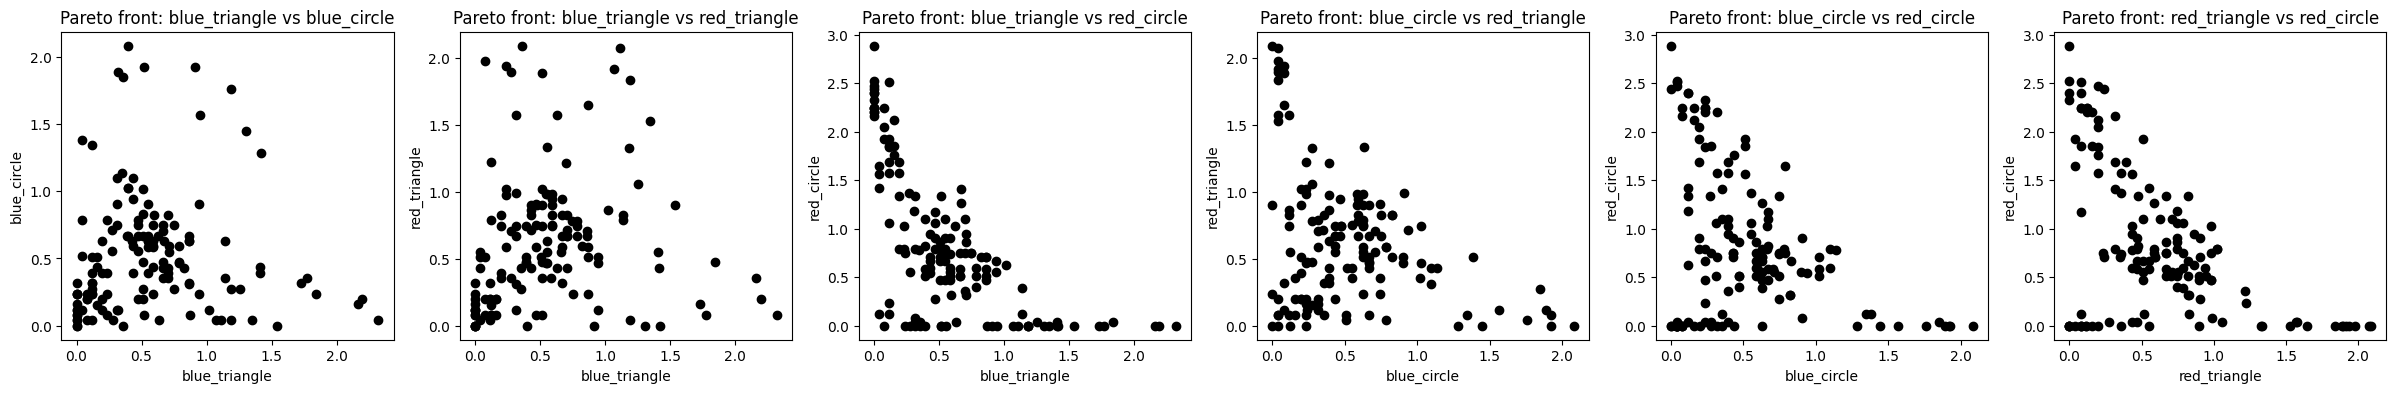

charts/SPS,█▇▆▆▆▅▅▅▅▄▄▄▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
eval/cardinality,▁▂▃▄▅▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇████████
eval/eum,▁▂▂▂▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇█████
eval/hypervolume,▁▃▃▇▇███████████████████████████████████
eval_0/discounted_vec_0,▄█▅█▁▇▅▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_0/discounted_vec_1,█▅▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_0/discounted_vec_2,▆▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_0/discounted_vec_3,▄▄▄▂▁▇█▇▇▆▃▇█▇▇▁▆█▄▅▅▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_0/scalarized_discounted_return,▂▃▃▃▆▅▇█▃▇▇▁▁▆█▂▆▆▇▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_0/scalarized_return,▁▃▇▇█▇▇█▃▇▁▂▂█▄▆▇▆▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+175,...


In [ ]:
env = gym.wrappers.TimeLimit(gym.make("my-four-room-v0"), max_episode_steps=MAX_EPISODE_LENGTH)
eval_env = gym.wrappers.TimeLimit(gym.make("my-four-room-v0"), max_episode_steps=MAX_EPISODE_LENGTH)

agent = MORLD(
    env=env,
    scalarization_method="ws",
    evaluation_mode="ser",
    policy_name="MOSACDiscrete",
    experiment_name=EXPERIMENT_NAME,
    pop_size=POP_SIZE,
    exchange_every=EXCHANGE_EVERY,
    log=True,
    policy_args={"learning_starts" : 0},
)

agent.train(
    total_timesteps=TOTAL_TIMESTEPS,
    eval_env=eval_env,
    ref_point=np.array([0, 0, 0, 0]),
    checkpoints=False,
)
visualize_front_general(agent.archive.evaluations, columns=["blue_triangle", "blue_circle", "red_triangle", "red_circle"])
agent.close_wandb()

Weights: [[0.         1.        ]
 [0.11037862 0.88962138]
 [0.2216579  0.7783421 ]
 [0.3329743  0.6670257 ]
 [0.44431167 0.55568833]
 [0.55574941 0.44425059]
 [0.6670048  0.3329952 ]
 [0.77836532 0.22163468]
 [0.88960597 0.11039403]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [2], [3], [6], [5], [8], [9], [8]]


wandb: ERROR Unable to save notebook session history.


charts/SPS,▁▄▆▆▇▇▇██████▇█████████▇█▇██████████████
eval/cardinality,▁▂▃▅▇███▇▇▄▄▅▅▅▅▅▅▅▅▅
eval/eum,▁▂▄▄▅▅▅▅▅▅▆▆█████████
eval/hypervolume,▁▁▄▄▄▄▄▄▅▅▆▆█████████
eval_0/discounted_vec_0,█▂▅▁▁▇▂▄▂▁▁▅▁▁▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_0/discounted_vec_1,▃▃▅▇▃▅▇▅▇▄▆▄▆▃▇█▆▆▅▅▂▄▃▂▂▄▄▂▂▃▂▃▃▆▁▁▁▁▁▁
eval_0/scalarized_discounted_return,▃▅▄▇▄▇▄▆▄▅▃▅▂▃▄█▆▄▅▅▂▂▃▂▁▅▇▂▃▂▂▂▂▂▆▁▁▂▁▂
eval_0/scalarized_return,▂▅▃▃▅▅▄▇▅▅▄▆▄▃█▅▄▂▃▂▄▄▂▂▂▂▃▁▃▂▄▆▂▁▁▂▂▁▁▂
eval_0/vec_0,█▂▁▂▁▇▇▂▄▁▁▁▁▂▁▂▁▄▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_0/vec_1,▅▂▇▃▅▄▅▇▅▅▃▂█▄▁▆▅▅▂▂▁▃▄▄▇▂▂▃▂▃▂▂▃▆▂▁▁▁▁▂
+135,...


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.2754388, 0.9409918]), array([0.70809651, 0.62556485]), array([0.31563479, 0.82750141]), array([0.47030037, 0.66908758]), array([0.70789652, 0.62909943]), array([0.78769057, 0.51088645])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Switching... global_steps: 2500
Updating other policies...
Current pareto archive:
[array([0.2754388, 0.9409918]), array([0.31563479, 0.82750141]), array([1.06411939, 0.7486895 ])]
[]
Adapting weights using PSA's method
New weights [array([0., 1.]), array([0.13053245, 0.86946755]), array([0.25627684, 0.74372316]), array([0.37656757, 0.62343243]), array([0.49173551, 0.50826449]), array([0.60217816, 0.39782184]), array([0.70791714, 0.29208286]), array([0.80950329, 0.19049671]), array([0.88960597, 0.11039403]), array([1., 0.])]
Global step: 2500
Save freq: 10000
Switching... global_steps: 5000
Updating other policies...
Current pareto archive:
[array([1.06411939, 0.7486895 ]), array([0.43266264, 1.41384448]), array([0.51324377, 1.13938298])]
[]
Adapting weights using PSA's method
New weights [array([0., 1.]), array([0.13053245, 0.86946755]), array([0.25627684, 0.74372316]), array([0.37656757, 0.62343243]), array([0.49173551, 0.50826449]), array([0.60217816, 0.39782184]), array([0.74571919

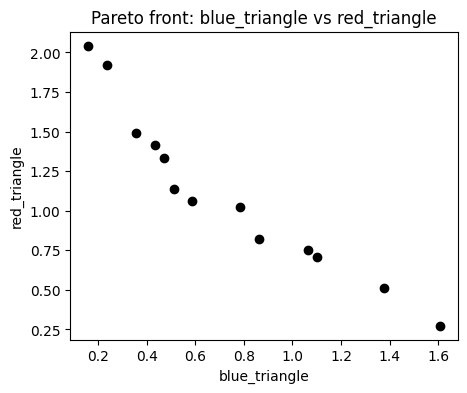

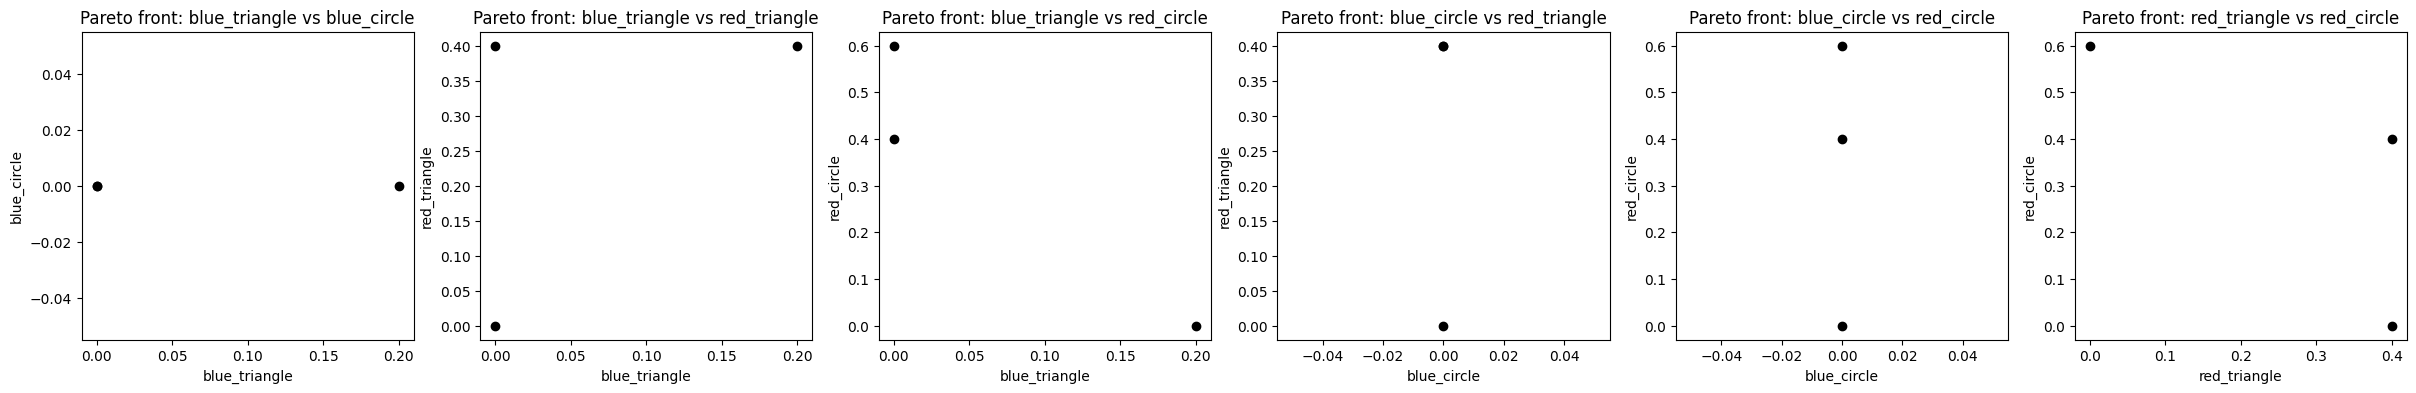

TypeError: The axis argument to unique is not supported for dtype object

In [28]:
# train only on triangle interpretation of the red and blue values
from morl_baselines.multi_policy.morld.morld import MORLD

triangle_weight = np.array([1.0, 0.0], dtype=np.float32)  # triangle interpretation
env = CombineWrapper(
    gym.wrappers.TimeLimit(gym.make("my-four-room-v0"), max_episode_steps=MAX_EPISODE_LENGTH),
    triangle_weight,
)
train_eval_env = CombineWrapper(
    gym.wrappers.TimeLimit(gym.make("my-four-room-v0"), max_episode_steps=MAX_EPISODE_LENGTH),
    triangle_weight,
)

agent = MORLD(
    env=env,
    scalarization_method="ws",
    evaluation_mode="ser",
    policy_name="MOSACDiscrete",
    experiment_name=EXPERIMENT_NAME + "_triangle_",
    pop_size=POP_SIZE,
    exchange_every=2500, # TODO
    log=True,
    weight_adaptation_method="PSA",
    policy_args={"learning_starts" : 500}
)
wandb.log({"interp_weight": triangle_weight})

agent.close_wandb = lambda : None # avoid closing wandb

agent.train(
    total_timesteps=TOTAL_TIMESTEPS // 2, # TODO
    eval_env=train_eval_env,
    ref_point=np.array([0, 0]),
    checkpoints=False
)
agent.save()

visualize_front_general(agent.archive.evaluations, columns=["blue_triangle", "red_triangle"])

eval_full_four_room(agent)

wandb.finish()

In [ ]:
agent.save()

Saving population...
Saving archive...


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


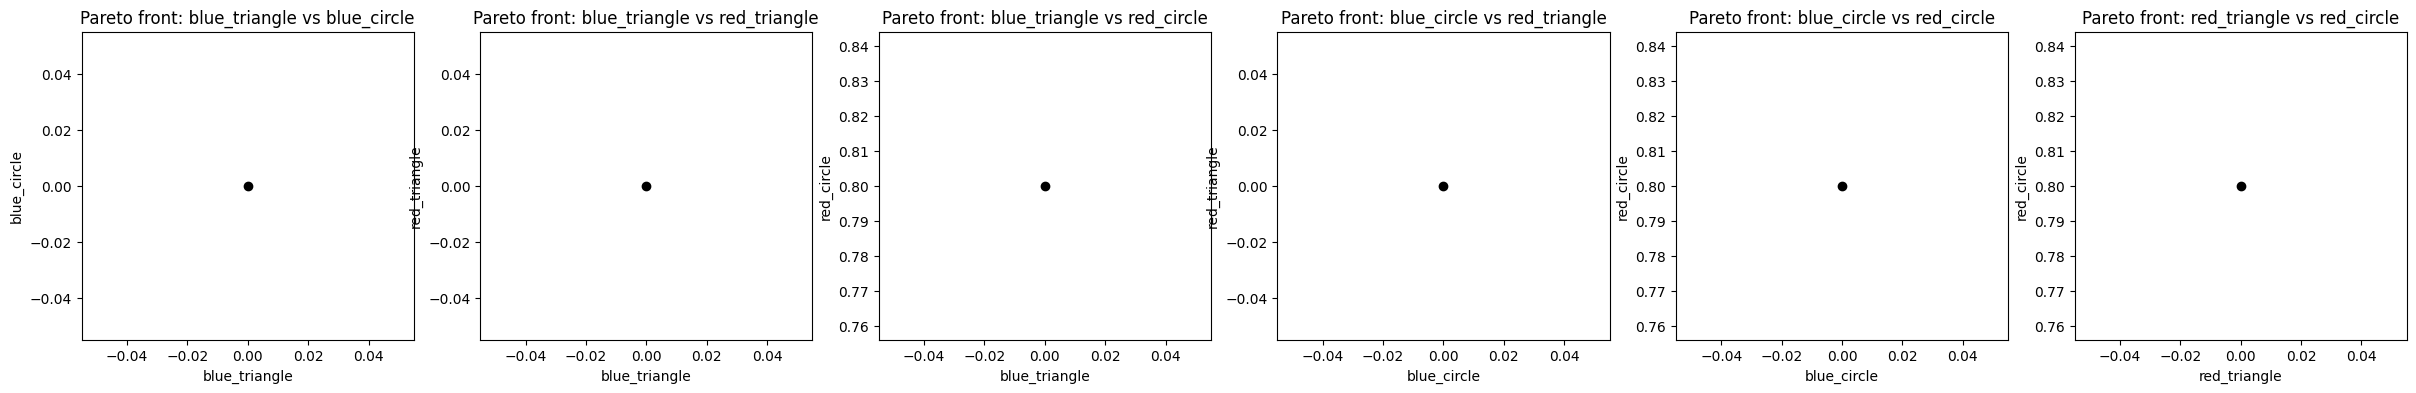

In [21]:
eval_full_four_room(agent)

Weights: [[0.         1.        ]
 [0.19914546 0.80085454]
 [0.39976866 0.60023134]
 [0.60048975 0.39951025]
 [0.80096818 0.19903182]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.08828743, 0.84200376]), array([0.37155634, 0.77998481]), array([0.37561051, 0.6840975 ])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.08828743, 0.84200376]), array([0.37155634, 0.77998481]), array([0.37561051, 0.6840975 ]), array([0.1112005 , 0.78507193])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
Switching... global_steps: 80000
Updating other policies...
Current pareto archive:
[array([0.37155634, 0.77998481]), array([0.37561051, 0.6840975 ]), array([0.1112005 , 0.78507193]), array([0.1096613 , 0.89489999]), array([0.02472155, 1.56803138]), array([0.44781641, 0.63560448])]
[]
Global step: 80000
Save freq: 10000
Saving checkpoint at step 80000
Saving population...
Saving archive...
Switching... global_steps: 120000
Updating other policies...
Current pareto archive:
[array([0.02472155, 1.56803138]), array([0.        , 1.66260167]), array([0.15194921, 1.49994336]), array([0.5319845 , 0.84105167])]
[]
Global step: 120000
Save freq: 10000
Saving checkpoint at s

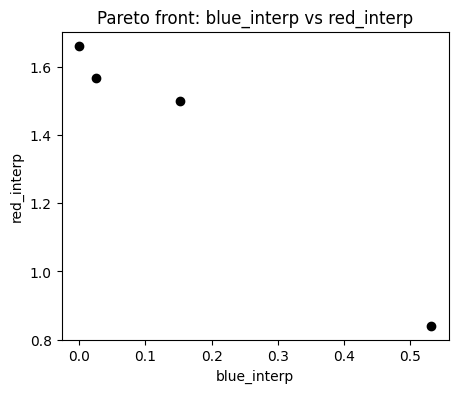

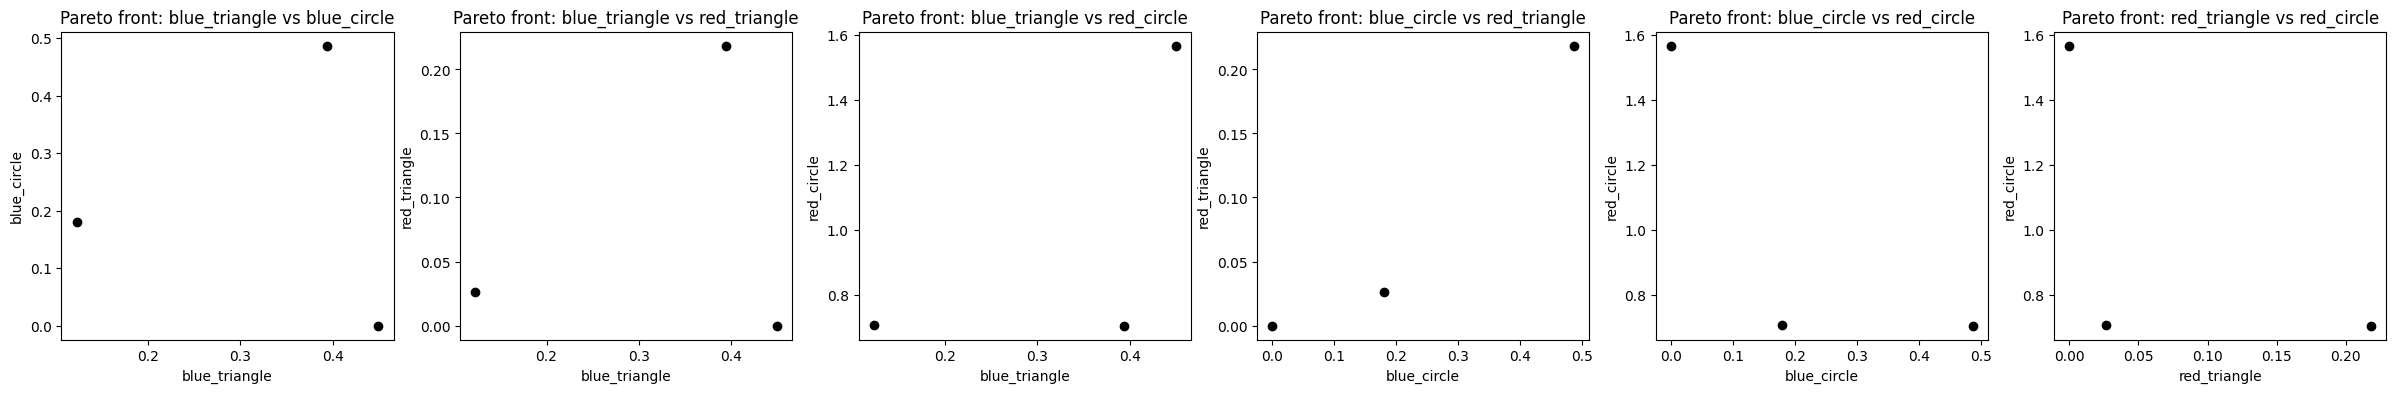

charts/SPS,█▇▆▆▄▃▃▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,▁▃█▃
eval/eum,▁▁▇█
eval/hypervolume,▁▁▃█
eval_0/discounted_vec_0,█▁▁▁▁▃▁▁▅▃▅▁▁▅▁▁▁▁▁▁▁▁▁▁▁
eval_0/discounted_vec_1,▆█▅▅█▅▇█▄▆▆█▆▇▆▁▁▁▁▁▁▁▁▁▁
eval_0/discounted_vec_2,▁▁▁▁▁
eval_0/discounted_vec_3,▁▁▁▁▁
eval_0/scalarized_discounted_return,▆█▅▅█▅▇█▄▆▆█▆▇▆▁▁▁▁▁▁▁▁▁▁
eval_0/scalarized_return,▆█▅▅█▅██▄▆▆█▆▇▇▁▁▁▁▁▁▁▁▁▁
+79,...


In [ ]:
# train only on circle 
weight_vec = np.array([0.0, 1.0], dtype=np.float32)  # circle interpretation
env = CombineWrapper(
    gym.wrappers.TimeLimit(gym.make("my-four-room-v0"), max_episode_steps=MAX_EPISODE_LENGTH),
    weight_vec,
)
eval_env = CombineWrapper(
    gym.wrappers.TimeLimit(gym.make("my-four-room-v0"), max_episode_steps=MAX_EPISODE_LENGTH),
    weight_vec,
)

agent = MORLD(
    env=env,
    scalarization_method="ws",
    evaluation_mode="ser",
    policy_name="MOSACDiscrete",
    experiment_name=EXPERIMENT_NAME + "_circle_",
)
wandb.log({"interp_weight": weight_vec})

agent.train(
    total_timesteps=TOTAL_TIMESTEPS,
    eval_env=eval_env,
    ref_point=np.array([0, 0]),
)
visualize_front_general(agent.archive.evaluations, columns=["blue_circle", "red_circle"])

eval_full_four_room(agent)

agent.close_wandb()


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Weight sweep:   0%|          | 0/10 [00:00<?, ?it/s]

Weights: [[0.         1.        ]
 [0.19914546 0.80085454]
 [0.39976866 0.60023134]
 [0.60048975 0.39951025]
 [0.80096818 0.19903182]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: kristofs (kristofs-ai) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.58654314, 0.62890434]), array([0.39464371, 0.98098089]), array([0.62575105, 0.11761893])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.58654314, 0.62890434]), array([0.39464371, 0.98098089]), array([0.15683672, 2.36072327]), array([0.6667243 , 0.62693218])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
Switching... global_steps: 80000
Updating other policies...
Current pareto archive:
[array([0.15683672, 2.36072327]), array([0.0796    , 2.71360173]), array([0.74849345, 2.35226719]), array([0.78651732, 0.66672822])]
[]
Global step: 80000
Save freq: 10000
Saving checkpoint at step 80000
Saving population...
Saving archive...
Switching... global_steps: 120000
Updating other policies...
Current pareto archive:
[array([0.0796    , 2.71360173]), array([0.74849345, 2.35226719]), array([0.19722482, 2.44720907]), array([1.61519099, 1.05782852])]
[]
Global step: 120000
Save freq: 10000
Saving checkpoint at step 120000
Saving population...
Saving archive...
done!


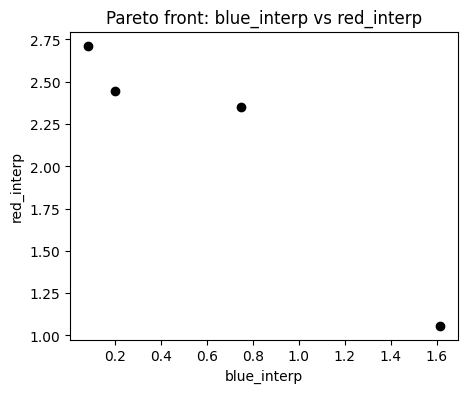

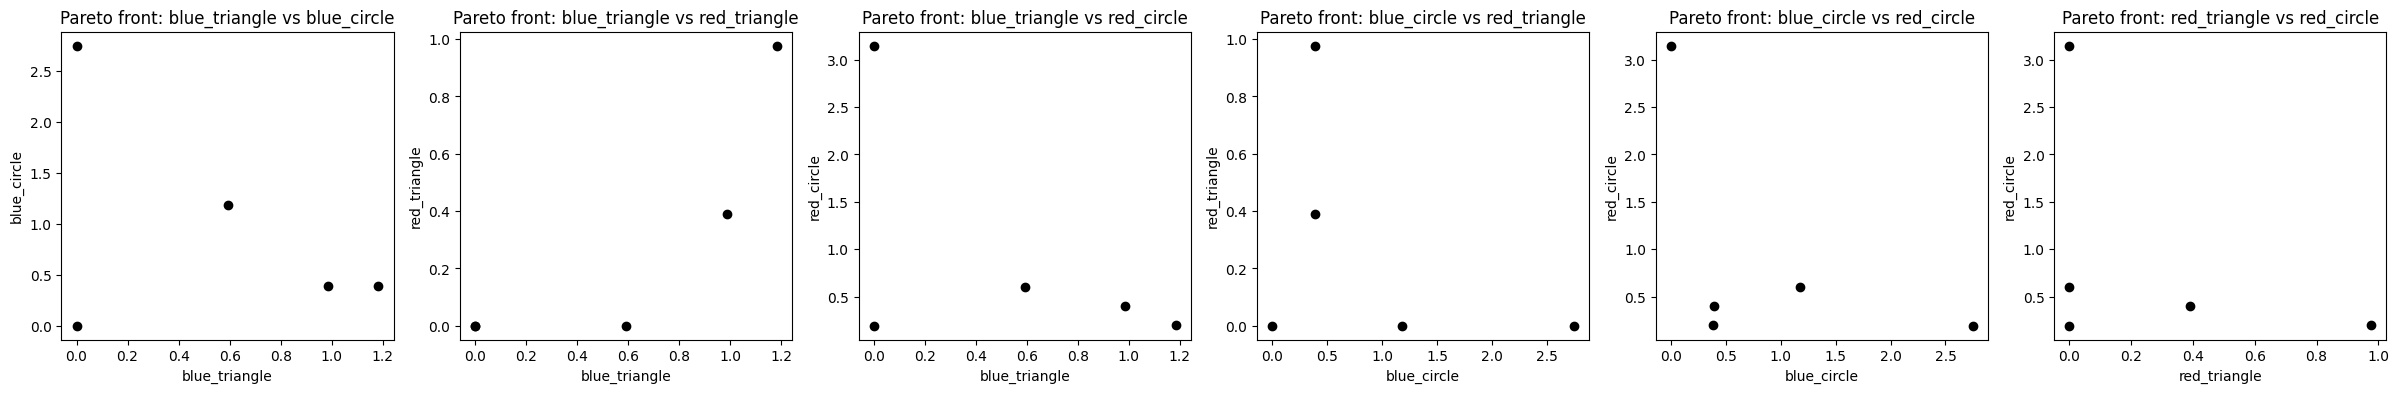

charts/SPS,█▆▅▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,▁███
eval/eum,▁▅▇█
eval/hypervolume,▁▂▅█
eval_0/discounted_vec_0,▅▅▅▅█▁▁▁▁█▃▁▁▃▁▁▁▁▁▁▁
eval_0/discounted_vec_1,▃▁▁▄▁▇█▅█▅██▇▇█▇▆▇▇▆▁
eval_0/discounted_vec_2,▁
eval_0/discounted_vec_3,▁
eval_0/scalarized_discounted_return,▃▁▁▄▁▇█▅█▅██▇▇█▇▆▇▇▆▂
eval_0/scalarized_return,▃▁▁▄▁▇█▅█▅██▇▇█▇▆▇▇▆▂
+79,...


Weight sweep:  10%|█         | 1/10 [09:20<1:24:08, 560.96s/it]

Weights: [[0.         1.        ]
 [0.19914546 0.80085454]
 [0.39976866 0.60023134]
 [0.60048975 0.39951025]
 [0.80096818 0.19903182]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.79803088, 0.57690796]), array([0.60762118, 0.58599747]), array([0.37086261, 0.81930593])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.79803088, 0.57690796]), array([0.17955105, 2.05944941]), array([0.78129874, 0.88219096])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
Switching... global_steps: 80000
Updating other policies...
Current pareto archive:
[array([0.79803088, 0.57690796]), array([0.78129874, 0.88219096]), array([0.25842842, 2.39398244]), array([0.31646568, 2.29251411]), array([0.79644133, 0.66502567])]
[]
Global step: 80000
Save freq: 10000
Saving checkpoint at step 80000
Saving population...
Saving archive...
Switching... global_steps: 120000
Updating other policies...
Current pareto archive:
[array([0.78129874, 0.88219096]), array([0.25842842, 2.39398244]), array([0.31646568, 2.29251411]), array([0.17618222, 2.45462657]), array([2.23660699, 0.66857497])]
[]
Global step: 120000
Save freq: 10000
Saving checkpoint at step 120000
Saving population...
S

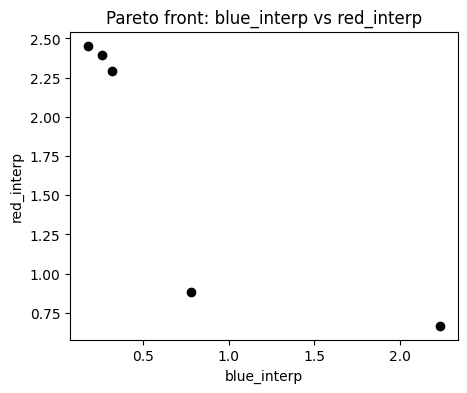

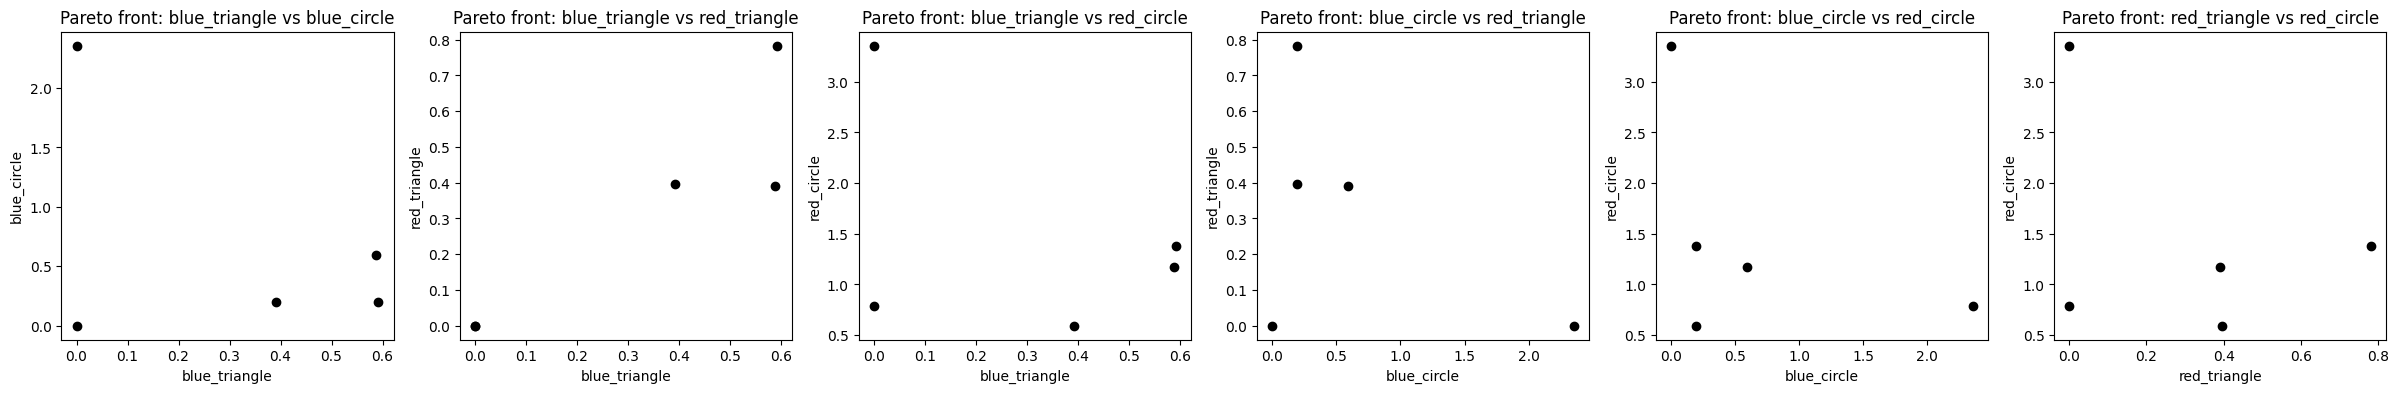

charts/SPS,█▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,▁▁██
eval/eum,▁▄▅█
eval/hypervolume,▁▃▄█
eval_0/discounted_vec_0,▅▂▄▂█▁▂▃▁▃▁▁▃▃▃▁▁▁▁▁▁
eval_0/discounted_vec_1,▂▂▄▃▂▅▅▇▆▆█▆▅█▇▃▂▄▄▅▁
eval_0/discounted_vec_2,▁
eval_0/discounted_vec_3,▁
eval_0/scalarized_discounted_return,▁▁▄▂▁▅▅▇▆▅█▆▅█▇▃▂▄▄▅▁
eval_0/scalarized_return,▁▁▄▂▁▅▅▇▆▅█▆▅█▇▃▂▄▄▅▁
+79,...


Weight sweep:  20%|██        | 2/10 [21:23<1:27:26, 655.83s/it]

Weights: [[0.         1.        ]
 [0.19914546 0.80085454]
 [0.39976866 0.60023134]
 [0.60048975 0.39951025]
 [0.80096818 0.19903182]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.68489643, 0.86458396]), array([0.74714325, 0.60968153]), array([0.95813418, 0.40188956])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.68489643, 0.86458396]), array([0.74714325, 0.60968153]), array([0.95813418, 0.40188956]), array([0.06099397, 1.92063726])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
Switching... global_steps: 80000
Updating other policies...
Current pareto archive:
[array([0.95813418, 0.40188956]), array([0.06099397, 1.92063726]), array([0.03095556, 2.1866993 ]), array([0.79240605, 1.55931134])]
[]
Global step: 80000
Save freq: 10000
Saving checkpoint at step 80000
Saving population...
Saving archive...
Switching... global_steps: 120000
Updating other policies...
Current pareto archive:
[array([0.95813418, 0.40188956]), array([0.03095556, 2.1866993 ]), array([0.79240605, 1.55931134]), array([0.34490548, 2.09344319]), array([1.96900562, 0.34762589])]
[]
Global step: 120000
Save freq: 10000
Saving checkpoint at step 120000
Saving population...
S

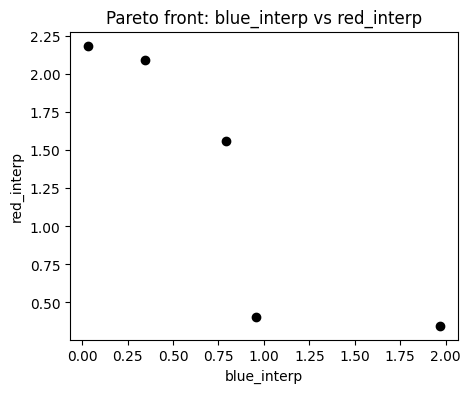

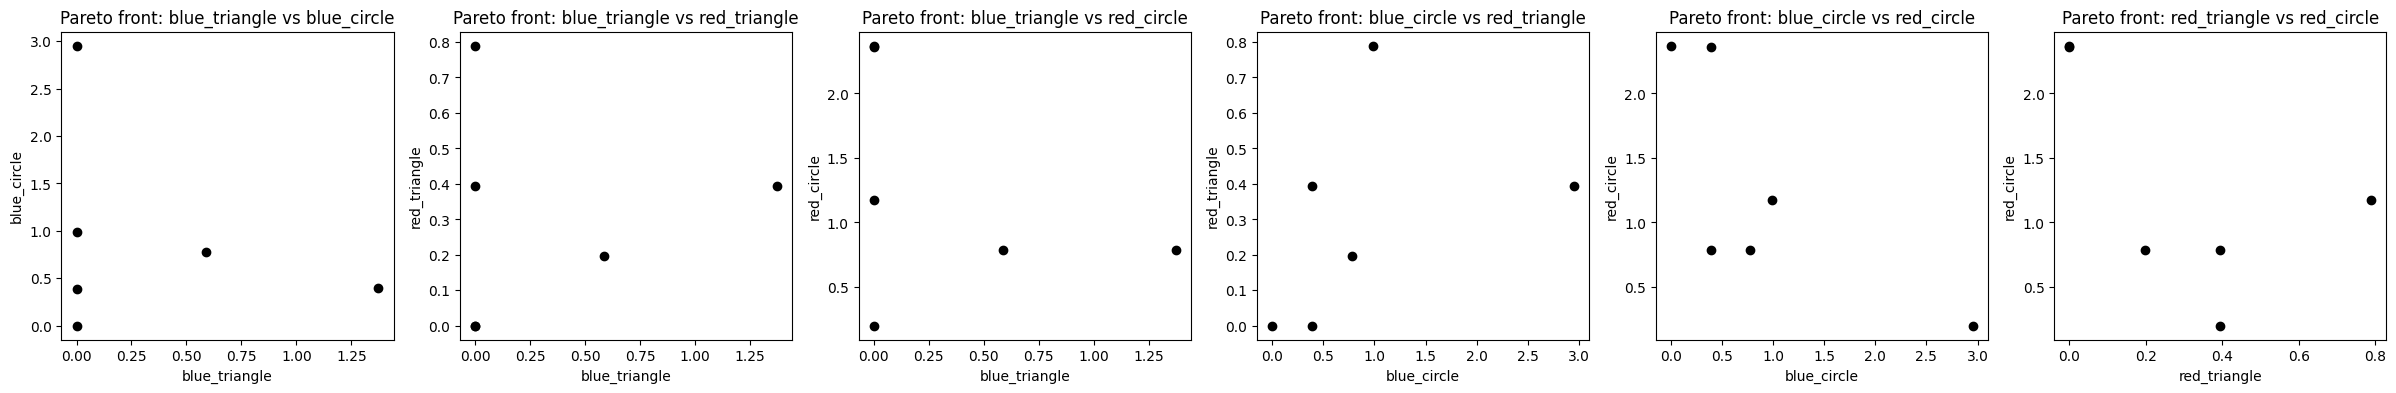

charts/SPS,█▆▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,▁▅▅█
eval/eum,▁▄▅█
eval/hypervolume,▁▁▅█
eval_0/discounted_vec_0,▅█▅▁▂▂▁▂▁▁▁▁▂▁▁▁▁▁▁▁▁
eval_0/discounted_vec_1,▁▂▁▅▁▆▅▇█▇██▇▇▇▆▇▇▇▆▁
eval_0/discounted_vec_2,▁
eval_0/discounted_vec_3,▁
eval_0/scalarized_discounted_return,▁▂▁▅▁▆▅▇█▇██▇▇▇▆▇▇▇▆▃
eval_0/scalarized_return,▁▂▁▅▁▆▅▇█▇██▇▇▇▆▇▇▇▆▃
+79,...


Weight sweep:  30%|███       | 3/10 [32:27<1:16:56, 659.52s/it]

Weights: [[0.         1.        ]
 [0.19914546 0.80085454]
 [0.39976866 0.60023134]
 [0.60048975 0.39951025]
 [0.80096818 0.19903182]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.71913522, 0.72163705]), array([0.90440714, 0.287853  ])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.71913522, 0.72163705]), array([0.90440714, 0.287853  ]), array([0.19571304, 1.77931982]), array([0.75789593, 0.32712926])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
Switching... global_steps: 80000
Updating other policies...
Current pareto archive:
[array([0.90440714, 0.287853  ]), array([0.19571304, 1.77931982]), array([0.75789593, 0.32712926]), array([0.09102485, 1.83846945]), array([0.27537443, 1.5441526 ]), array([0.74790406, 0.83808009])]
[]
Global step: 80000
Save freq: 10000
Saving checkpoint at step 80000
Saving population...
Saving archive...
Switching... global_steps: 120000
Updating other policies...
Current pareto archive:
[array([0.19571304, 1.77931982]), array([0.09102485, 1.83846945]), array([0.27537443, 1.5441526 ]), array([1.0475766, 1.2446087])]
[]
Global step: 120000
Save freq: 10000
Saving checkpoint at ste

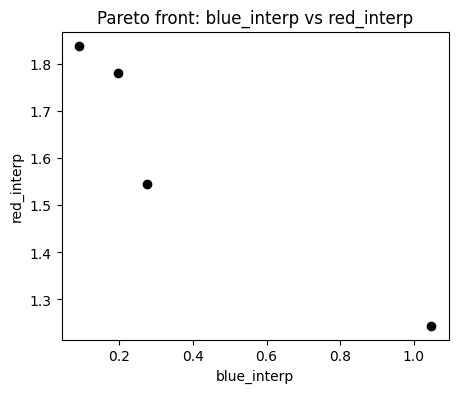

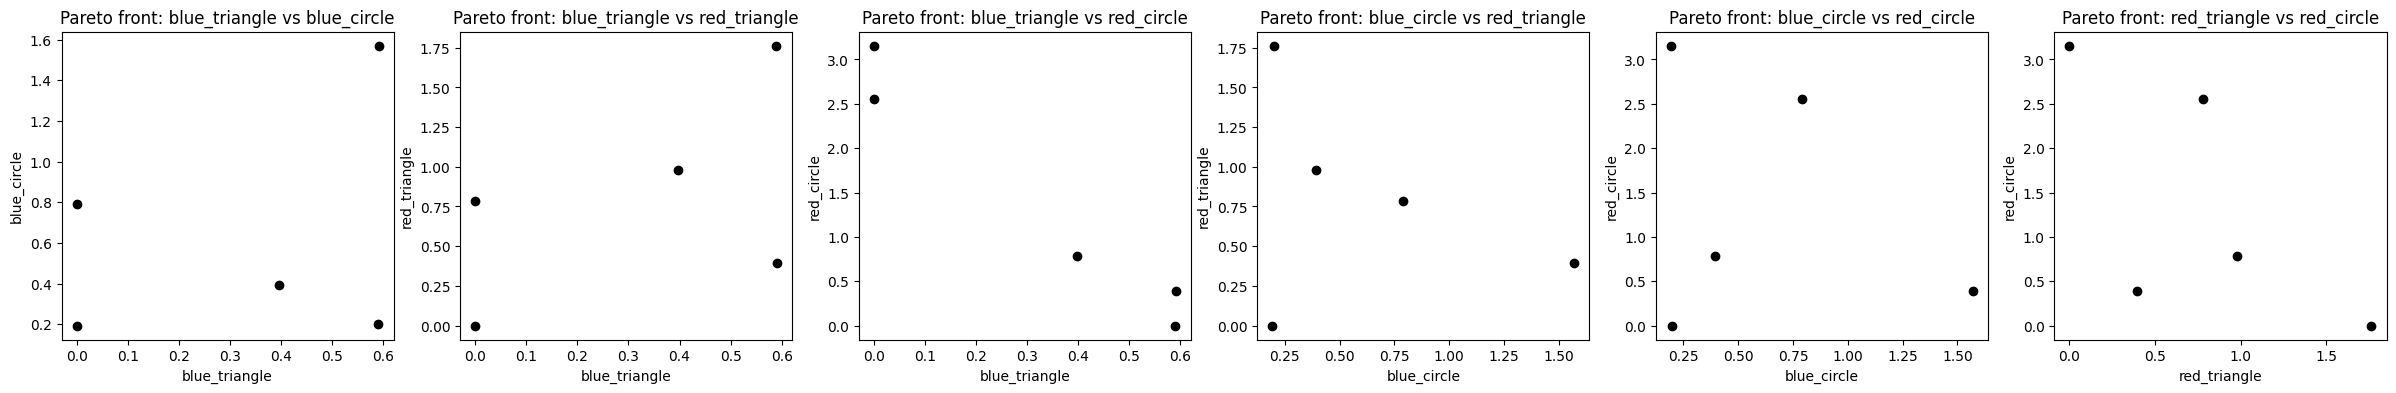

charts/SPS,██▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,▁▅█▅
eval/eum,▁▆▆█
eval/hypervolume,▁▃▄█
eval_0/discounted_vec_0,▃▆▄▅█▃▁▁▂▄▂▃▁▁▁▁▁▁▁▁▁
eval_0/discounted_vec_1,▃▃▄▄▃▇▇█▇▅▆▆█▇▇▅▆▆▆▆▁
eval_0/discounted_vec_2,▁
eval_0/discounted_vec_3,▁
eval_0/scalarized_discounted_return,▂▂▃▃▁▆▆▇▆▅▆▅█▇▆▄▅▅▅▅▁
eval_0/scalarized_return,▂▂▃▃▁▆▆▇▆▅▆▅█▇▆▄▅▅▅▅▁
+79,...


Weight sweep:  40%|████      | 4/10 [42:41<1:04:10, 641.69s/it]

Weights: [[0.         1.        ]
 [0.19914546 0.80085454]
 [0.39976866 0.60023134]
 [0.60048975 0.39951025]
 [0.80096818 0.19903182]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.50107479, 0.50299703]), array([0.30064081, 0.80092832]), array([1.08772268, 0.42791373]), array([0.76694815, 0.49238621])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.30064081, 0.80092832]), array([1.08772268, 0.42791373]), array([0.76694815, 0.49238621]), array([0.14426785, 1.57108285]), array([0.63301277, 0.57375741]), array([0.53605556, 0.73392159])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
Switching... global_steps: 80000
Updating other policies...
Current pareto archive:
[array([1.08772268, 0.42791373]), array([0.14426785, 1.57108285]), array([0.1751354 , 1.38885338]), array([0.82919811, 0.77895137]), array([0.4284461 , 0.81102312])]
[]
Global step: 80000
Save freq: 10000
Saving checkpoint at step 80000
Saving population...
Saving archive...
Switching... global_steps: 120000
Updating other policies...
Current pareto archive:
[array([1.08772268, 0.42791373]), array([0.14426785, 1.57108285]), array([0.82919811, 0.77895137]), array([0.4284461 , 0.81102312]), array([0.34544392, 1.39707888

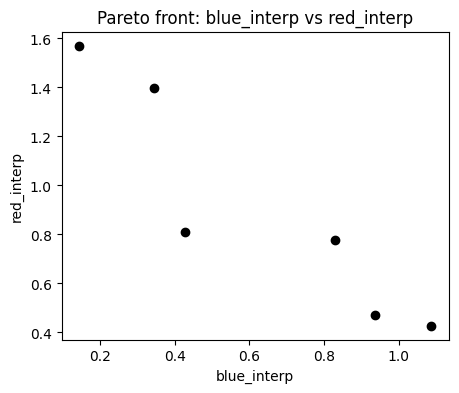

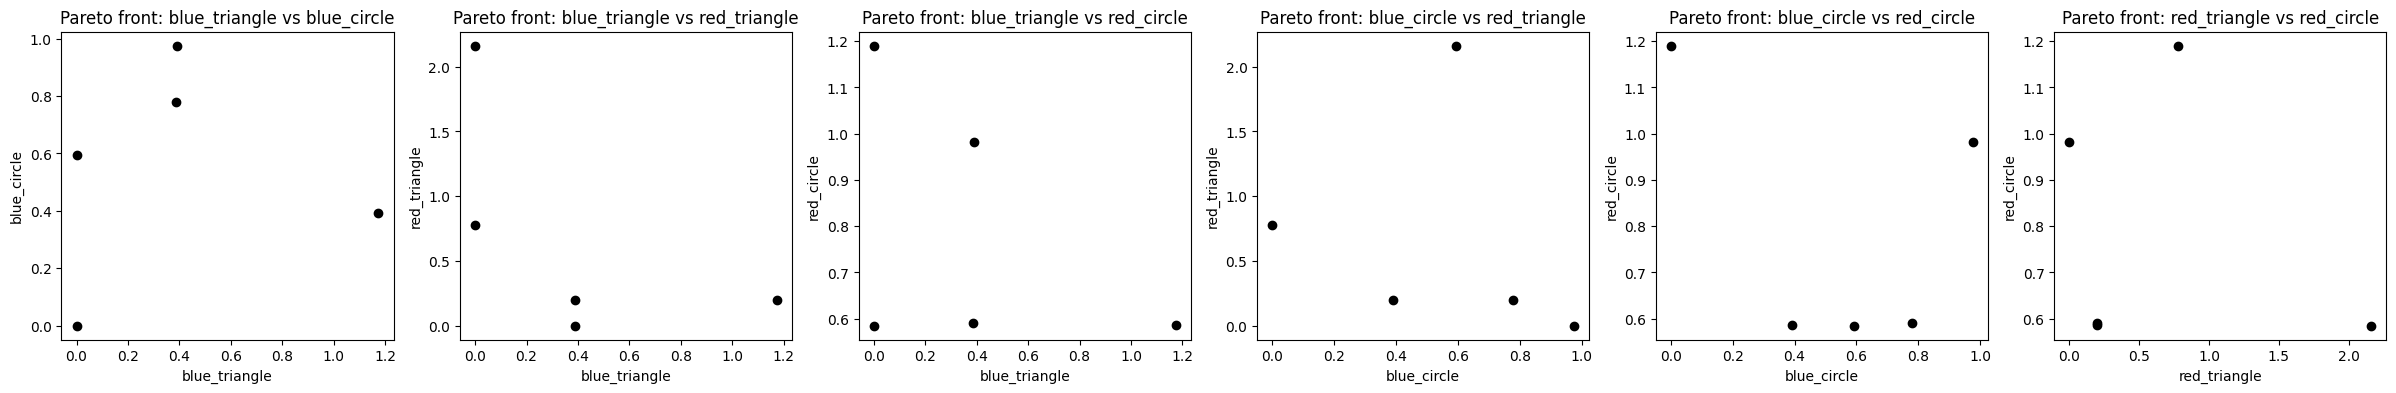

charts/SPS,█▇▆▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,▁█▅█
eval/eum,▁███
eval/hypervolume,▁▄▆█
eval_0/discounted_vec_0,▄▇▅█▇▁▁▄▃▁▄▁▁▁▁▁▁▁▁▁▁
eval_0/discounted_vec_1,▃▂▃▃▃▇▇▅▆█▅▆▇▆▆▃▃▃▂▃▁
eval_0/discounted_vec_2,▁
eval_0/discounted_vec_3,▁
eval_0/scalarized_discounted_return,▂▁▂▂▃▇▇▄▆█▅▆▇▆▆▂▃▂▁▂▁
eval_0/scalarized_return,▂▁▂▂▃▇▇▄▆█▅▆▇▆▆▂▃▂▁▂▁
+79,...


Weight sweep:  50%|█████     | 5/10 [53:09<53:03, 636.66s/it]  

Weights: [[0.         1.        ]
 [0.19914546 0.80085454]
 [0.39976866 0.60023134]
 [0.60048975 0.39951025]
 [0.80096818 0.19903182]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.4018853 , 0.88205105]), array([0.45378976, 0.69790148]), array([0.69377254, 0.55572733])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.4018853 , 0.88205105]), array([0.45378976, 0.69790148]), array([0.08347275, 1.53451583]), array([0.63139875, 0.61627036]), array([0.94998391, 0.3151497 ]), array([0.8055679 , 0.61532587])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
Switching... global_steps: 80000
Updating other policies...
Current pareto archive:
[array([0.4018853 , 0.88205105]), array([0.08347275, 1.53451583]), array([0.94998391, 0.3151497 ]), array([0.8055679 , 0.61532587]), array([0.1045564 , 1.52408951]), array([0.6330188, 0.8797426])]
[]
Global step: 80000
Save freq: 10000
Saving checkpoint at step 80000
Saving population...
Saving archive...
Switching... global_steps: 120000
Updating other policies...
Current pareto archive:
[array([0.08347275, 1.53451583]), array([0.94998391, 0.3151497 ]), array([0.8055679 , 0.61532587]), array([0.1045564 , 1.52408951])

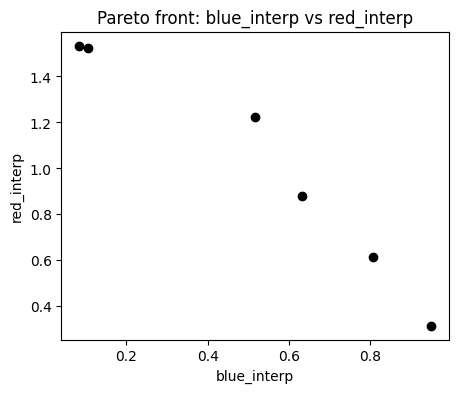

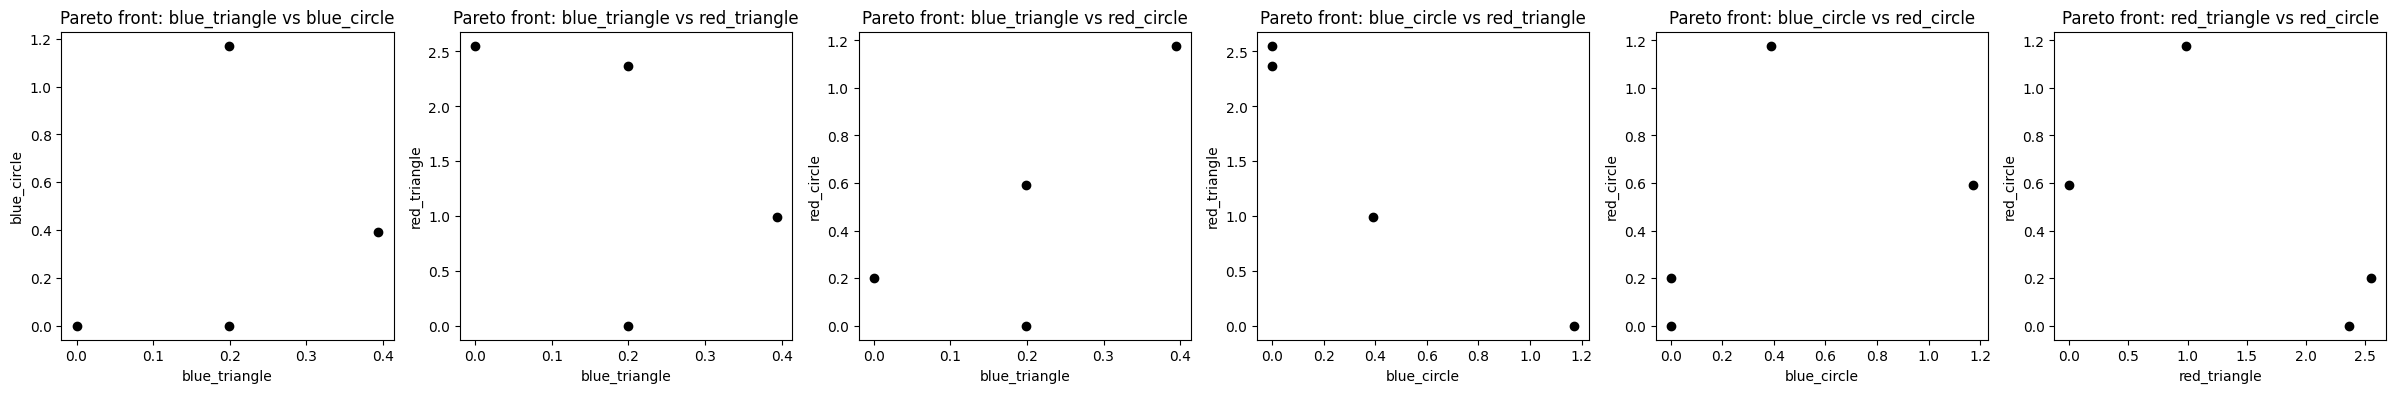

charts/SPS,█▇▆▄▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,▁███
eval/eum,▁███
eval/hypervolume,▁▄▅█
eval_0/discounted_vec_0,▅█▂▅▅▃▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁
eval_0/discounted_vec_1,▅▄▆▂▅█▆▇▆█▇▅▇▇▇▁▁▁▁▁▁
eval_0/discounted_vec_2,▁
eval_0/discounted_vec_3,▁
eval_0/scalarized_discounted_return,▅▄▆▂▅█▆▇▆█▇▅▇▇▇▁▁▁▁▁▁
eval_0/scalarized_return,▅▄▆▂▅█▆▇▆█▇▅▇▇▇▁▁▁▁▁▁
+79,...


Weight sweep:  60%|██████    | 6/10 [1:03:31<42:07, 631.78s/it]

Weights: [[0.         1.        ]
 [0.19914546 0.80085454]
 [0.39976866 0.60023134]
 [0.60048975 0.39951025]
 [0.80096818 0.19903182]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.57354439, 0.60144866]), array([0.68091959, 0.53597007]), array([0.28687053, 0.6935926 ]), array([0.39234254, 0.60387364]), array([0.8795797 , 0.48356505])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.8795797 , 0.48356505]), array([0.34006823, 1.5719849 ]), array([0.75788675, 0.70803708])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
Switching... global_steps: 80000
Updating other policies...
Current pareto archive:
[array([0.8795797 , 0.48356505]), array([0.34006823, 1.5719849 ]), array([0.75788675, 0.70803708]), array([0.01300332, 1.93969109]), array([1.16402592, 0.18467631])]
[]
Global step: 80000
Save freq: 10000
Saving checkpoint at step 80000
Saving population...
Saving archive...
Switching... global_steps: 120000
Updating other policies...
Current pareto archive:
[array([0.8795797 , 0.48356505]), array([0.34006823, 1.5719849 ]), array([0.75788675, 0.70803708]), array([0.01300332, 1.93969109]), array([1.16402592, 0.18467631]), array([0.78651963, 0.61608591]), array([1.02227927, 0.28844506])]
[]
Global step: 120000
Save f

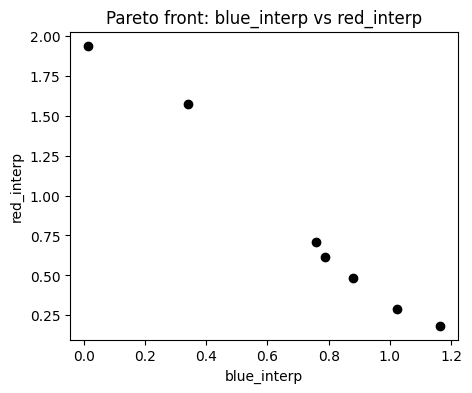

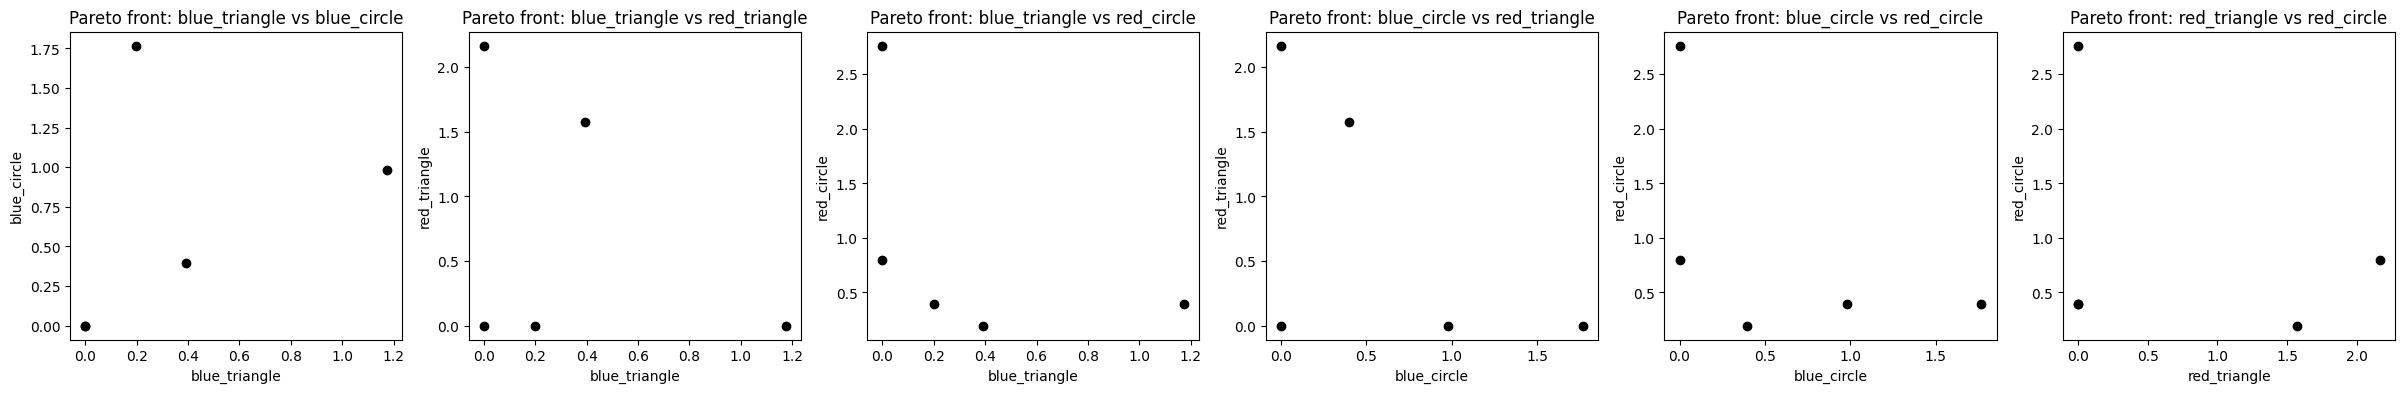

charts/SPS,█▅▄▄▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,▅▁▅█
eval/eum,▁▆██
eval/hypervolume,▁▇██
eval_0/discounted_vec_0,▃▄▄▅█▅▁▃▁▆▁▁▁▁▁▁▁▁▁▁▁
eval_0/discounted_vec_1,▄▂▃▄▂▆▆▆▇▆▆████▁▁▁▁▁▁
eval_0/discounted_vec_2,▁
eval_0/discounted_vec_3,▁
eval_0/scalarized_discounted_return,▄▂▃▄▂▆▆▆▇▆▆████▁▁▁▁▁▁
eval_0/scalarized_return,▄▂▃▄▂▆▆▆▇▆▆████▁▁▁▁▁▁
+79,...


Weight sweep:  70%|███████   | 7/10 [1:14:35<32:06, 642.25s/it]

Weights: [[0.         1.        ]
 [0.19914546 0.80085454]
 [0.39976866 0.60023134]
 [0.60048975 0.39951025]
 [0.80096818 0.19903182]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.44347784, 0.7935549 ]), array([0.5911352 , 0.72095142]), array([0.30935358, 0.95585423]), array([0.68983755, 0.39089947]), array([0.6781564 , 0.60225684])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.30935358, 0.95585423]), array([0.13135253, 2.07015996]), array([1.14518956, 0.39560483]), array([1.03656834, 0.93952237])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
Switching... global_steps: 80000
Updating other policies...
Current pareto archive:
[array([0.13135253, 2.07015996]), array([1.14518956, 0.39560483]), array([1.03656834, 0.93952237]), array([0.36584072, 1.68625449])]
[]
Global step: 80000
Save freq: 10000
Saving checkpoint at step 80000
Saving population...
Saving archive...
Switching... global_steps: 120000
Updating other policies...
Current pareto archive:
[array([1.14518956, 0.39560483]), array([1.03656834, 0.93952237]), array([0.39796524, 2.11223833])]
[]
Global step: 120000
Save freq: 10000
Saving checkpoint at step 120000
Saving population...
Saving archive...
done!


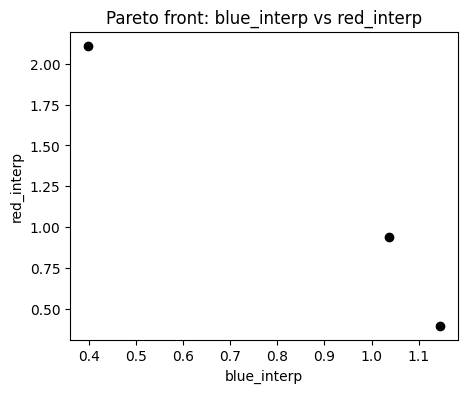

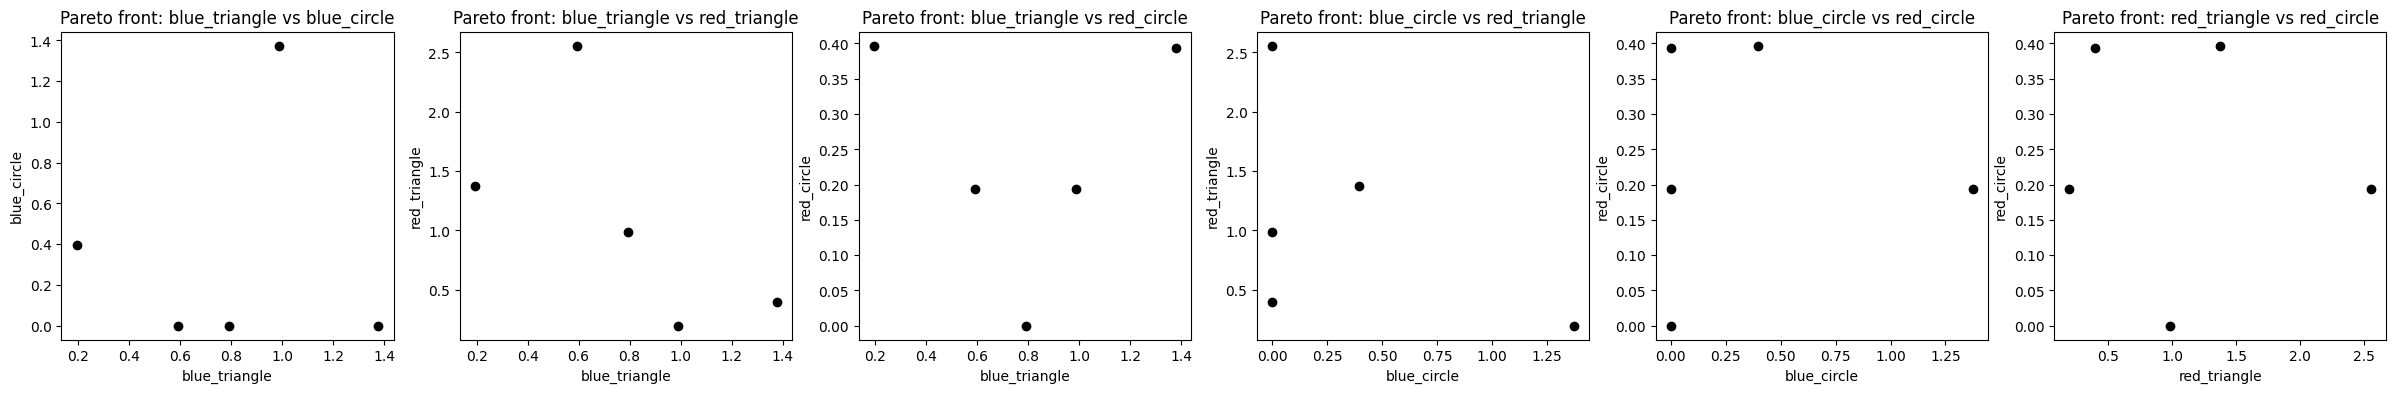

charts/SPS,█▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,█▅▅▁
eval/eum,▁▇▇█
eval/hypervolume,▁▆▇█
eval_0/discounted_vec_0,▆▃▇▆█▁▁▄▄▁▁▂▁▁▁▁▁▁▁▁▁
eval_0/discounted_vec_1,▂▂▃▂▃█▆▆▇▅▇█▆▅▆▁▁▂▁▁▁
eval_0/discounted_vec_2,▁
eval_0/discounted_vec_3,▁
eval_0/scalarized_discounted_return,▂▂▃▂▃█▆▆▇▅▇█▆▅▆▁▁▂▁▁▁
eval_0/scalarized_return,▂▂▃▂▃█▆▆▇▅▇█▆▅▆▁▁▂▁▁▁
+79,...


Weight sweep:  80%|████████  | 8/10 [1:23:35<20:19, 609.68s/it]

Weights: [[0.         1.        ]
 [0.19914546 0.80085454]
 [0.39976866 0.60023134]
 [0.60048975 0.39951025]
 [0.80096818 0.19903182]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.83139762, 0.5589126 ]), array([0.61520392, 0.71992821]), array([0.53413363, 0.75121201])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.83139762, 0.5589126 ]), array([0.61520392, 0.71992821]), array([0.53413363, 0.75121201]), array([0.21514894, 2.19407795]), array([0.31686301, 0.78649076])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
Switching... global_steps: 80000
Updating other policies...
Current pareto archive:
[array([0.83139762, 0.5589126 ]), array([0.61520392, 0.71992821]), array([0.53413363, 0.75121201]), array([0.21514894, 2.19407795]), array([0.        , 2.28665543]), array([0.17815703, 2.26592808]), array([0.91635576, 0.5111633 ]), array([0.45997814, 0.78678947])]
[]
Global step: 80000
Save freq: 10000
Saving checkpoint at step 80000
Saving population...
Saving archive...
Switching... global_steps: 120000
Updating other policies...
Current pareto archive:
[array([0.21514894, 2.19407795]), array([0.        , 2.28665543]), array([0.17815703, 2.26592808

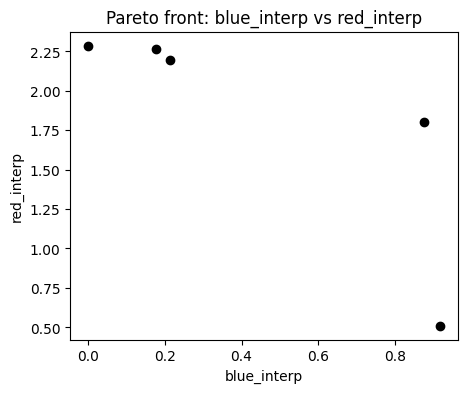

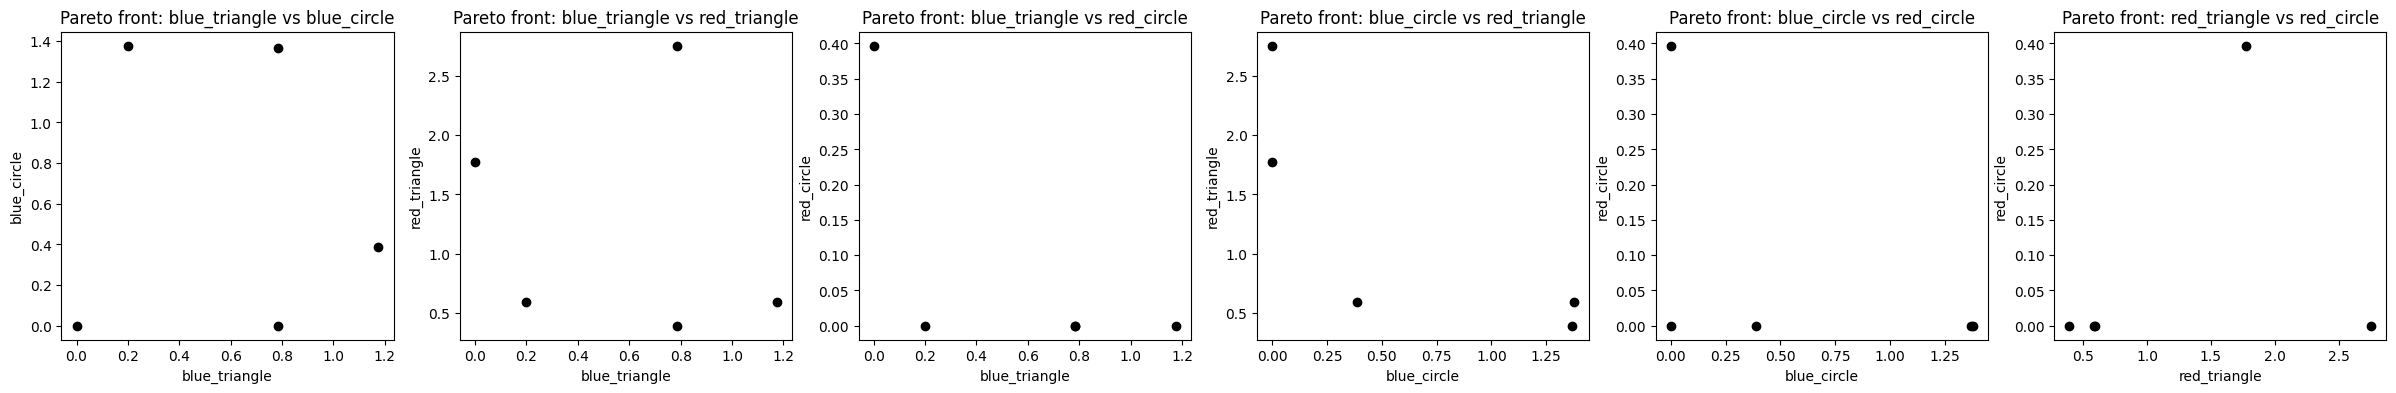

charts/SPS,█▅▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,▁▄█▄
eval/eum,▁▇▇█
eval/hypervolume,▁▃▃█
eval_0/discounted_vec_0,▃█▄▇▄▁▁▄▃▅▁▁▁▁▁▁▁▁▁▁▁
eval_0/discounted_vec_1,▂▁▂▃▂▇▇▇▆▅▅▆██▇▂▁▂▁▁▁
eval_0/discounted_vec_2,▁
eval_0/discounted_vec_3,▁
eval_0/scalarized_discounted_return,▂▁▂▃▂▇▇▇▆▅▅▆██▇▂▁▂▁▁▁
eval_0/scalarized_return,▂▁▂▃▂▇▇▇▆▅▅▆██▇▂▁▂▁▁▁
+79,...


Weight sweep:  90%|█████████ | 9/10 [1:32:25<09:45, 585.00s/it]

Weights: [[0.         1.        ]
 [0.19914546 0.80085454]
 [0.39976866 0.60023134]
 [0.60048975 0.39951025]
 [0.80096818 0.19903182]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


Starting training...
Current pareto archive:
[array([0.86413531, 0.66634895]), array([0.50990432, 1.05998887])]
[]


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be <class 'numpy.float32'>, actual type: int32
  logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Switching... global_steps: 40000
Updating other policies...
Current pareto archive:
[array([0.86413531, 0.66634895]), array([0.50990432, 1.05998887]), array([0.15761693, 2.75006316]), array([0.55028648, 0.82278274])]
[]
Global step: 40000
Save freq: 10000
Saving checkpoint at step 40000
Saving population...
Saving archive...
Switching... global_steps: 80000
Updating other policies...
Current pareto archive:
[array([0.50990432, 1.05998887]), array([0.15761693, 2.75006316]), array([0.55028648, 0.82278274]), array([0.90199661, 0.66869253]), array([0.5100964 , 1.02079763])]
[]
Global step: 80000
Save freq: 10000
Saving checkpoint at step 80000
Saving population...
Saving archive...
Switching... global_steps: 120000
Updating other policies...
Current pareto archive:
[array([0.50990432, 1.05998887]), array([0.15761693, 2.75006316]), array([0.55028648, 0.82278274]), array([0.90199661, 0.66869253]), array([0.5100964 , 1.02079763]), array([0.43011816, 2.47441852])]
[]
Global step: 120000
Save f

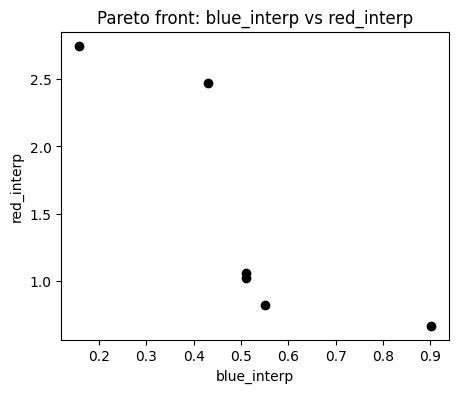

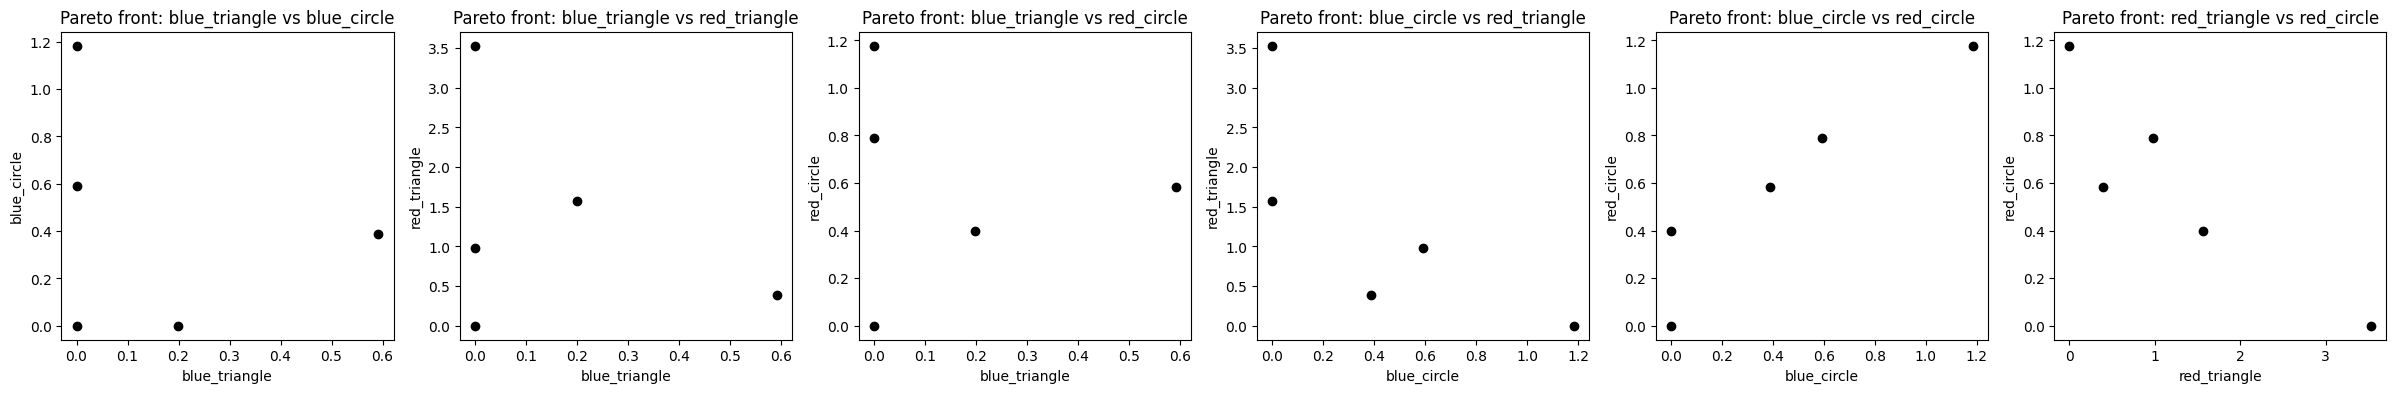

charts/SPS,█▄▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/cardinality,▁▅▆█
eval/eum,▁███
eval/hypervolume,▁▄▄█
eval_0/discounted_vec_0,█▃▂▇▂▁▁▁▆▁▂▁▁▁▁▁▁▁▁▁▁
eval_0/discounted_vec_1,▃▃▁▁▂▄▆▇▆█▆▅▆▄▇▁▁▂▁▂▁
eval_0/discounted_vec_2,▁
eval_0/discounted_vec_3,▁
eval_0/scalarized_discounted_return,▃▃▁▁▂▄▆▇▆█▆▅▆▄▇▁▁▂▁▂▁
eval_0/scalarized_return,▃▃▁▁▂▅▆▇▆█▆▅▆▄▇▁▁▂▁▂▁
+79,...


Weight sweep: 100%|██████████| 10/10 [1:40:56<00:00, 605.65s/it]


{0.0: array([[0.0796    , 2.71360173],
        [0.74849345, 2.35226719],
        [0.19722482, 2.44720907],
        [1.61519099, 1.05782852]]),
 0.1111111111111111: array([[0.78129874, 0.88219096],
        [0.25842842, 2.39398244],
        [0.31646568, 2.29251411],
        [0.17618222, 2.45462657],
        [2.23660699, 0.66857497]]),
 0.2222222222222222: array([[0.95813418, 0.40188956],
        [0.03095556, 2.1866993 ],
        [0.79240605, 1.55931134],
        [0.34490548, 2.09344319],
        [1.96900562, 0.34762589]]),
 0.3333333333333333: array([[0.19571304, 1.77931982],
        [0.09102485, 1.83846945],
        [0.27537443, 1.5441526 ],
        [1.0475766 , 1.2446087 ]]),
 0.4444444444444444: array([[1.08772268, 0.42791373],
        [0.14426785, 1.57108285],
        [0.82919811, 0.77895137],
        [0.4284461 , 0.81102312],
        [0.34544392, 1.39707888],
        [0.93709401, 0.47012415]]),
 0.5555555555555556: array([[0.08347275, 1.53451583],
        [0.94998391, 0.3151497 ],
 

In [ ]:
# train on weighted scalarization between triangle and circle

all_fronts = {}

weights = np.linspace(0.0, 1.0, 10)
for i, w_triangle in enumerate(tqdm(weights, desc="Weight sweep")):
    w_circle = 1.0 - w_triangle
    weight_vec = np.array([w_triangle, w_circle], dtype=np.float32)

    env = CombineWrapper(
        gym.wrappers.TimeLimit(
            gym.make("my-four-room-v0"), max_episode_steps=MAX_EPISODE_LENGTH
        ),
        weight_vec,
    )
    eval_env = CombineWrapper(
        gym.wrappers.TimeLimit(
            gym.make("my-four-room-v0"), max_episode_steps=MAX_EPISODE_LENGTH
        ),
        weight_vec,
    )

    agent = MORLD(
        env=env,
        scalarization_method="ws",
        evaluation_mode="ser",
        policy_name="MOSACDiscrete",
        pop_size=POP_SIZE,
        exchange_every=EXCHANGE_EVERY,
        experiment_name=EXPERIMENT_NAME + f"_w{w_triangle:.2f}:{w_circle:.2f}",
    )

    wandb.log({"interp_weight": weight_vec})

    agent.train(
        total_timesteps=TOTAL_TIMESTEPS,
        eval_env=eval_env,
        ref_point=np.array([0, 0]),
    )

    all_fronts[float(w_triangle)] = np.array(agent.archive.evaluations)
    visualize_front_general(
        agent.archive.evaluations,
        columns=["blue_interp", "red_interp"],
    )

    eval_full_four_room(agent)
    agent.close_wandb()

# Optional: inspect all fronts by weight
all_fronts

In [ ]:
# train on weighted scalarization between triangle and circle
from tqdm.auto import tqdm

all_fronts = {}

w_triangle = 0.0
# weights = np.linspace(0.0, 1.0, 10)
# for i, w_triangle in enumerate(tqdm(weights, desc="Weight sweep")):
w_circle = 1.0 - w_triangle
weight_vec = np.array([w_triangle, w_circle], dtype=np.float32)

env = CombineWrapper(
    gym.wrappers.TimeLimit(gym.make("my-four-room-v0"), max_episode_steps=MAX_EPISODE_LENGTH),
    weight_vec,
)
eval_env = CombineWrapper(
    gym.wrappers.TimeLimit(gym.make("my-four-room-v0"), max_episode_steps=MAX_EPISODE_LENGTH),
    weight_vec,
)

agent = MORLD(
    env=env,
    scalarization_method="ws",
    evaluation_mode="ser",
    policy_name="MOSACDiscrete",
    experiment_name=EXPERIMENT_NAME + f"_w{w_triangle:.2f}:{w_circle:.2f}",
    exchange_every=100
)

agent.train(
    total_timesteps=TOTAL_TIMESTEPS,
    eval_env=eval_env,
    ref_point=np.array([0, 0]),
)

all_fronts[float(w_triangle)] = np.array(agent.archive.evaluations)
visualize_front_general(
    agent.archive.evaluations,
    columns=["blue_interp", "red_interp"],
)

eval_full_four_room(agent)
agent.close_wandb()